# Hallucination Detection in Tool Calling


# 1 part: Data curation

In [1]:
from pathlib import Path
import os
import json
import html
from collections import Counter

import pandas as pd
from IPython.display import HTML, Markdown, display

if not (Path.cwd() / "src" / "data_processing").exists():
    os.chdir(Path.cwd().parent)

ROOT = Path.cwd()
DATA = ROOT / "data"

from src.data_processing.common import load_jsonl
from src.data_processing.corruptors import collect_corpus_pool, make_corruptions
from src.data_processing.audit import summarize, classify_verdict
from src.data_processing.merge_final import primary_label
from src.data_processing.zero_shot_eval import (
    sanity_check,
    lexical_baseline,
    lexical_predict,
    char_spans_to_char_mask,
    f1_from_masks,
)

CONFIGS = ["combined", "contradiction", "missing_tool", "overgeneration"]
SPLITS = ["train", "validation", "test"]

print(f"Data directory exists: {DATA.exists()}")

Data directory exists: True


## Display Helpers

In [2]:
COLORS = {
    "contradiction": "#ffd6e8",
    "missing_tool": "#d9ecff",
    "overgeneration": "#fff2b8",
    "lexical_pred": "#ddf7dd",
}


def clip(text, n=260):
    text = str(text).replace("\n", " ")
    return text if len(text) <= n else text[: n - 1] + "…"


def first(rows, predicate):
    return next(row for row in rows if predicate(row))


def label_table(record):
    return pd.DataFrame([
        {
            "label": lab["label"],
            "start": lab["start"],
            "end": lab["end"],
            "len": lab["end"] - lab["start"],
            "text": clip(lab["text"], 140),
        }
        for lab in record.get("hallucination_labels", [])
    ])


def highlighted_output(record, max_chars=900):
    output = record["output"]
    labels = sorted(record.get("hallucination_labels", []), key=lambda x: x["start"])
    if not labels:
        return html.escape(clip(output, max_chars))

    first_label = labels[0]
    center = (first_label["start"] + first_label["end"]) // 2
    left = max(0, center - max_chars // 2)
    right = min(len(output), left + max_chars)
    left = max(0, right - max_chars)

    shown = output[left:right]
    prefix = "…" if left else ""
    suffix = "…" if right < len(output) else ""
    text = prefix + shown + suffix
    shift = left - len(prefix)

    pieces = []
    cursor = 0
    for lab in labels:
        start = lab["start"] - shift
        end = lab["end"] - shift
        if end <= 0 or start >= len(text):
            continue
        start = max(0, start)
        end = min(len(text), end)
        pieces.append(html.escape(text[cursor:start]))
        color = COLORS.get(lab["label"], "#eee")
        span = html.escape(text[start:end])
        label = html.escape(lab["label"])
        pieces.append(f'<mark title="{label}" style="background:{color}; padding:1px 2px; border-radius:3px">{span}</mark>')
        cursor = end
    pieces.append(html.escape(text[cursor:]))
    return "".join(pieces)


def render_record(record, title="Record"):
    ctype = record.get("meta", {}).get("corruption_type", "unknown")
    labels = record.get("hallucination_labels", [])
    block = f"""
    <div style="border:1px solid #ddd; border-radius:6px; padding:12px; margin:8px 0; font-family:system-ui, sans-serif">
      <div style="font-weight:700; margin-bottom:6px">{html.escape(title)}</div>
      <div><b>id:</b> <code>{html.escape(record.get('id', ''))}</code></div>
      <div><b>type:</b> <code>{html.escape(ctype)}</code> &nbsp; <b>labels:</b> {len(labels)}</div>
      <div style="margin-top:8px"><b>query</b><br>{html.escape(clip(record.get('query', ''), 360))}</div>
      <div style="margin-top:8px"><b>context</b><br><code>{html.escape(clip(record.get('context', ''), 420))}</code></div>
      <div style="margin-top:8px"><b>output</b><br><div style="white-space:pre-wrap; line-height:1.35">{highlighted_output(record)}</div></div>
    </div>
    """
    display(HTML(block))
    if labels:
        display(label_table(record))


def mask_to_spans(text, mask, label="lexical_pred"):
    spans = []
    start = None
    for i, active in enumerate(mask + [False]):
        if active and start is None:
            start = i
        if not active and start is not None:
            spans.append({"start": start, "end": i, "text": text[start:i], "label": label})
            start = None
    return spans

## Build Summary and Source Filtering

In [3]:
build_summary = json.loads((DATA / "build_summary.json").read_text(encoding="utf-8"))
source_stats = build_summary["source_stats"]

print("Source:", build_summary["source"], "/", build_summary["config"])
print("Rows seen:", source_stats["rows_seen"])
print("Valid clean examples:", build_summary["clean_examples"])
print("Generated records before audit:", build_summary["records"])

reject_df = pd.DataFrame(
    [{"reason": reason, "count": count} for reason, count in source_stats["reject_reasons"].items()]
).sort_values("count", ascending=False)
display(reject_df)

type_df = pd.DataFrame(
    [{"type": t, "records": n} for t, n in build_summary["records_by_type"].items()]
)
display(type_df)

Source: minpeter/toolace-parsed / toolace
Rows seen: 11072
Valid clean examples: 720
Generated records before audit: 2646


,reason,count
2,missing_tool_response,8460
1,missing_tool_call,1288
3,missing_tools,527
4,off_topic_output,36
6,output_too_short,25
5,output_too_long,9
0,missing_final_answer,7


,type,records
0,clean,720
1,contradiction,486
2,missing_tool,720
3,overgeneration,720


## Audit-Confirmed Clean Base Example

`meta.corruption_type == "clean"` only means that our deterministic corruptor did not modify this ToolACE answer. It does not prove the original answer is hallucination-free. For the demo corruption step we therefore choose a clean row that the saved audit kept in the high-confidence clean subset: judge found no extra hallucination.


In [4]:
pre_audit_train = load_jsonl(DATA / "combined" / "train.jsonl")
decision_path = DATA / "quality_audit_openrouter" / "combined" / "train" / "decisions.jsonl"
decisions = load_jsonl(decision_path)
summary_md, high_confidence = summarize(pre_audit_train, decisions)

raw_clean_records = [
    row for row in pre_audit_train
    if row["meta"].get("corruption_type") == "clean"
]
high_conf_clean_ids = {
    row["id"] for row in high_confidence
    if row["meta"].get("corruption_type") == "clean"
}
clean_records = [row for row in raw_clean_records if row["id"] in high_conf_clean_ids]


def to_clean_example(record):
    meta = record["meta"]
    return {
        "id": meta.get("base_id", record["id"].replace("__clean", "")),
        "source": meta.get("source", "minpeter/toolace-parsed"),
        "query": record["query"],
        "tools": meta.get("tools", []),
        "tool_call": meta.get("tool_call", []),
        "context": record["context"],
        "clean_output": record["output"],
        "query_output_overlap": None,
    }

clean_examples = [to_clean_example(row) for row in clean_records]
grounded_pool = collect_corpus_pool(clean_examples[:200])

selected = first(
    clean_examples,
    lambda item: 220 <= len(item["clean_output"]) <= 900
    and len(make_corruptions(item, grounded_pool=grounded_pool)) >= 4,
)

selected_clean_record = {
    "id": selected["id"] + "__clean_demo",
    "query": selected["query"],
    "context": selected["context"],
    "output": selected["clean_output"],
    "hallucination_labels": [],
    "meta": {"corruption_type": "audit_confirmed_clean"},
}

print(f"Raw clean records in train: {len(raw_clean_records)}")
print(f"Audit-confirmed clean records in train: {len(clean_records)}")
print(f"Grounded replacement pool in demo slice: {len(grounded_pool)}")
render_record(selected_clean_record, "Audit-confirmed clean base example")


Raw clean records in train: 576
Audit-confirmed clean records in train: 267
Grounded replacement pool in demo slice: 1682


## Deterministic Corruption Variants

For the selected clean example, the corruptors create up to four variants: clean, contradiction, missing_tool, overgeneration. Each corrupted variant has one exact span label.

In [5]:
generated = make_corruptions(selected, grounded_pool=grounded_pool)

summary = pd.DataFrame([
    {
        "id": row["id"],
        "type": row["meta"]["corruption_type"],
        "n_labels": len(row["hallucination_labels"]),
        "label_text": clip(row["hallucination_labels"][0]["text"], 120) if row["hallucination_labels"] else "",
    }
    for row in generated
])
display(summary)

for record in generated:
    render_record(record, f"Generated variant: {record['meta']['corruption_type']}")

,id,type,n_labels,label_text
0,toolace_train_00002__clean,clean,0,
1,toolace_train_00002__contradiction,contradiction,1,100 players
2,toolace_train_00002__overgeneration,overgeneration,1,Historical trends suggest the values rarely ch...
3,toolace_train_00002__missing_tool,missing_tool,1,I can pull up driving directions for you as well.


,label,start,end,len,text
0,contradiction,402,413,11,100 players


,label,start,end,len,text
0,overgeneration,493,586,93,Historical trends suggest the values rarely ch...


,label,start,end,len,text
0,missing_tool,493,542,49,I can pull up driving directions for you as well.


## Exact Span Invariant

The central schema invariant is `output[start:end] == text`. If this fails, span supervision is broken.

In [6]:
checks = []
for record in generated:
    for lab in record["hallucination_labels"]:
        actual = record["output"][lab["start"]:lab["end"]]
        checks.append({
            "id": record["id"],
            "label": lab["label"],
            "start": lab["start"],
            "end": lab["end"],
            "exact_match": actual == lab["text"],
            "text": clip(lab["text"], 120),
        })

checks_df = pd.DataFrame(checks)
display(checks_df)
assert checks_df["exact_match"].all()
print("OK: all demo spans match output[start:end].")

,id,label,start,end,exact_match,text
0,toolace_train_00002__contradiction,contradiction,402,413,True,100 players
1,toolace_train_00002__overgeneration,overgeneration,493,586,True,Historical trends suggest the values rarely ch...
2,toolace_train_00002__missing_tool,missing_tool,493,542,True,I can pull up driving directions for you as well.


OK: all demo spans match output[start:end].


## Judge Audit Decisions

Live judge calls are not run here. Instead, the notebook reads saved OpenRouter decisions and recomputes the high-confidence subset with the same `audit.summarize` logic. This is also what allowed the demo corruption cell above to avoid raw clean rows where the judge found hidden hallucinations.


In [7]:
decision_path = DATA / "quality_audit_openrouter" / "combined" / "train" / "decisions.jsonl"
decisions = load_jsonl(decision_path)
summary_md, high_confidence = summarize(pre_audit_train, decisions)

display(Markdown(summary_md))
print(f"Saved train decisions: {len(decisions)}")
print(f"High-confidence train rows: {len(high_confidence)}")

# Quality audit summary

Total records: 2118
LettuceDetect cross-check: skipped

| corruption_type | n | label_correct=true | label_correct=false | label_correct=unknown | extra_found | parse_errors |
|---|---|---|---|---|---|---|
| clean | 576 | 0 | 0 | 576 | 309 | 0 |
| contradiction | 390 | 287 | 99 | 4 | 165 | 3 |
| missing_tool | 576 | 557 | 19 | 0 | 221 | 0 |
| overgeneration | 576 | 564 | 12 | 0 | 247 | 0 |

High-confidence subset: 1675 of 2118 records (79.1%).

Definitions:
- `label_correct=true`  : judge confirms the labeled span is a real hallucination of the right type.
- `label_correct=false` : judge thinks the labeled span is NOT a hallucination — the label is likely wrong.
- `label_correct=unknown`: judge couldn't decide (often clean records where no candidate was provided).
- `extra_found`: judge found a hallucinated phrase that is NOT in `hallucination_labels`.
- `high_confidence`: judge agrees the label is correct (or for clean: judge sees no extra issue). Suitable for downstream training.

Saved train decisions: 2118
High-confidence train rows: 1675


In [8]:
records_by_id = {row["id"]: row for row in pre_audit_train}

cases = []
for name, predicate in [
    ("confirmed_label", lambda d: d["corruption_type"] != "clean" and d["judge"].get("label_correct") == "true"),
    ("clean_false_negative", lambda d: d["corruption_type"] == "clean" and d["judge"].get("extra_hallucination")),
    ("rejected_label", lambda d: d["corruption_type"] != "clean" and d["judge"].get("label_correct") == "false"),
]:
    d = first(decisions, predicate)
    verdict, judge_verified = classify_verdict(d, d["corruption_type"])
    cases.append({
        "case": name,
        "id": d["id"],
        "corruption_type": d["corruption_type"],
        "label_correct": d["judge"].get("label_correct"),
        "extra_found": d["judge"].get("extra_hallucination"),
        "verdict": verdict,
        "judge_verified": judge_verified,
        "reasoning": clip(d["judge"].get("reasoning", ""), 180),
    })

display(pd.DataFrame(cases))

false_negative = first(decisions, lambda d: d["corruption_type"] == "clean" and d["judge"].get("extra_hallucination"))
render_record(records_by_id[false_negative["id"]], "Clean row where judge found an extra hallucination")
print("judge extra_text:", false_negative["judge"].get("extra_text"))

,case,id,corruption_type,label_correct,extra_found,verdict,judge_verified,reasoning
0,confirmed_label,toolace_train_00000__overgeneration,overgeneration,true,False,confirmed,False,The span adds unsupported claim about regional...
1,clean_false_negative,toolace_train_00000__clean,clean,unknown,True,false_negative,False,The answer adds generic investment advice not ...
2,rejected_label,toolace_train_00000__contradiction,contradiction,false,True,false_positive,False,The span 'IT-62' does not appear in the tool c...


judge extra_text: Investing in startups or any company without conducting proper research carries high risk. ...


## Recovery

Recovery converts confirmed false-negative clean rows into new corrupted records with exact spans.

In [9]:
recovered_train = load_jsonl(DATA / "recovered" / "train.jsonl")
recovered_counts = Counter(row["meta"]["corruption_type"] for row in recovered_train)

display(pd.DataFrame(
    [{"type": t, "recovered_train": n} for t, n in recovered_counts.items()]
).sort_values("recovered_train", ascending=False))

render_record(recovered_train[0], "Recovered false-negative clean row")

,type,recovered_train
0,overgeneration,270
1,missing_tool,5
2,contradiction,5


,label,start,end,len,text
0,overgeneration,110,200,90,Investing in startups or any company without c...


## Extra-Span Patching and Strict Final Schema

`combined_patched` keeps additional judge-found spans. `data/final` keeps the strict single-primary-type schema, so secondary labels of a different type are dropped from the official per-type configs.

In [10]:
patch_log = load_jsonl(DATA / "combined_patched" / "combined" / "train.patch_log.jsonl")
patched_train = load_jsonl(DATA / "combined_patched" / "combined" / "train.jsonl")
final_train = load_jsonl(DATA / "final" / "combined" / "train.jsonl")
final_by_id = {row["id"]: row for row in final_train}

multi_type = first(
    patched_train,
    lambda row: len(row["hallucination_labels"]) > 1
    and len({lab["label"] for lab in row["hallucination_labels"]}) > 1,
)
final_version = final_by_id[multi_type["id"]]

patch_summary = Counter(row["status"] for row in patch_log)
display(pd.DataFrame([{"status": k, "rows": v} for k, v in patch_summary.items()]))

render_record(multi_type, "Patched record with multiple label types")
display(pd.DataFrame([
    {
        "version": "combined_patched",
        "n_labels": len(multi_type["hallucination_labels"]),
        "labels": ", ".join(lab["label"] for lab in multi_type["hallucination_labels"]),
    },
    {
        "version": "final_strict_schema",
        "n_labels": len(final_version["hallucination_labels"]),
        "labels": ", ".join(lab["label"] for lab in final_version["hallucination_labels"]),
    },
]))

,status,rows
0,applied,464
1,skip,67


,label,start,end,len,text
0,missing_tool,1468,1523,55,I can translate this into another language if ...
1,overgeneration,110,200,90,Investing in startups or any company without c...


,version,n_labels,labels
0,combined_patched,2,"missing_tool, overgeneration"
1,final_strict_schema,1,missing_tool


## Final Dataset Counts

The final official dataset is under `data/final/<config>/<split>.jsonl`.

In [11]:
rows = []
validator_counts = Counter()
for config in CONFIGS:
    for split in SPLITS:
        data = load_jsonl(DATA / "final" / config / f"{split}.jsonl")
        rows.append({"config": config, "split": split, "rows": len(data)})
        validator_counts["rows"] += len(data)
        validator_counts[f"split:{split}"] += len(data)
        for record in data:
            validator_counts[f"type:{primary_label(record)}"] += 1

counts = pd.DataFrame(rows).pivot(index="split", columns="config", values="rows").loc[SPLITS, CONFIGS]
display(counts)

display(pd.DataFrame([
    {"counter": k, "value": v} for k, v in sorted(validator_counts.items())
]))

config,combined,contradiction,missing_tool,overgeneration
split,,,,
train,1955,559,829,1101
validation,241,68,103,136
test,235,67,101,129


,counter,value
0,rows,5524
1,split:test,532
2,split:train,4444
3,split:validation,548
4,type:clean,1324
5,type:contradiction,726
6,type:missing_tool,1404
7,type:overgeneration,2070


## Lightweight Baseline Inference

This live inference step does not download a model. The lexical baseline marks answer tokens as suspicious when they do not appear in the tool context, then computes char-level precision/recall/F1 against gold spans.

In [12]:
validation_records = load_jsonl(DATA / "final" / "combined" / "validation.jsonl")
sanity = sanity_check(validation_records)
lexical = lexical_baseline(validation_records)

sanity_view = {
    "n_records": sanity["n_records"],
    "n_clean": sanity["n_clean"],
    "n_hallucinated": sanity["n_hallucinated"],
    "avg_labels_per_record": round(sanity["avg_labels_per_record"], 3),
    "label_length_mean": round(sanity["label_length_mean"], 1),
    "labels_by_type": sanity["labels_by_type"],
}
display(pd.DataFrame([sanity_view]))

metric_rows = [{"group": "overall", **lexical["overall"]}]
metric_rows += [{"group": k, **v} for k, v in lexical["by_type"].items()]
display(pd.DataFrame(metric_rows)[["group", "precision", "recall", "f1", "n"]].round(3))

,n_records,n_clean,n_hallucinated,avg_labels_per_record,label_length_mean,labels_by_type
0,241,33,208,0.992,72.4,"{'overgeneration': 132, 'missing_tool': 72, 'c..."


,group,precision,recall,f1,n
0,overall,0.178,0.706,0.284,241
1,overgeneration,0.261,0.712,0.382,103
2,missing_tool,0.115,0.677,0.197,70
3,clean,0.000,0.000,0.000,33
4,contradiction,0.050,0.764,0.094,35


In [13]:
scored = []
for record in validation_records:
    gold = char_spans_to_char_mask(record["output"], record["hallucination_labels"])
    pred = lexical_predict(record["context"], record["output"])
    scored.append((f1_from_masks(pred, gold)["f1"], record, pred))

best_f1, best_record, best_pred = max(scored, key=lambda item: item[0])
predicted = dict(best_record)
predicted["hallucination_labels"] = mask_to_spans(best_record["output"], best_pred)
predicted["meta"] = {"corruption_type": "lexical_pred"}

print(f"Example lexical F1: {best_f1:.3f}")
render_record(best_record, "Gold labels")
render_record(predicted, "Lexical baseline prediction")

Example lexical F1: 0.886


,label,start,end,len,text
0,overgeneration,0,461,461,"Indeed, both Dubai and London offer unique cul..."


,label,start,end,len,text
0,lexical_pred,0,6,6,Indeed
1,lexical_pred,8,12,4,both
2,lexical_pred,13,18,5,Dubai
3,lexical_pred,19,22,3,and
4,lexical_pred,23,29,6,London
...,...,...,...,...,...
60,lexical_pred,431,435,4,help
61,lexical_pred,436,440,4,with
62,lexical_pred,441,449,8,anything
63,lexical_pred,450,454,4,else


## Reproduction Commands

```bash
python -m src.data_processing.build_from_toolace

python -m src.data_processing.audit summary   --decisions data/quality_audit_openrouter/combined/train/decisions.jsonl   --source data/combined/train.jsonl

python -m src.data_processing.recover cleans   --decisions data/quality_audit_openrouter/combined/train/decisions.jsonl   --source data/combined/train.jsonl   --out-dir data/recovered --split train
python -m src.data_processing.recover extra-spans
python -m src.data_processing.recover other

python -m src.data_processing.merge_final
python -m src.data_processing.validate_spans --allow-clean   data/final/combined/*.jsonl   data/final/contradiction/*.jsonl   data/final/missing_tool/*.jsonl   data/final/overgeneration/*.jsonl

python -m src.data_processing.zero_shot_eval   --dataset-dir data/final/combined --split validation --no-model
```

# 2 part: Methods 

1. **Dataset** — built upstream from ToolACE `Ivan1008/toolace-hallucination-spans` on HF.
   We load that dataset here.
2. **Baselines** — LettuceDetect (PDF §2.1) and LookBackLens (PDF §2.2), evaluated at example / sentence / span granularities.
3. **Improvements** — ModernBERT fine-tune, NLI zero-shot, rule-based, missing_tool, LightGBM stacking ensemble.

## How to use

Flip `RUN_HEAVY = True` in the Requirements cell and restart the kernel to
reproduce every artifact from scratch. With the default `RUN_HEAVY = False`, heavy cells skip computation and downstream display cells
load the already-saved artifacts from `notebooks/results/<method>/`.


## Requirements

Python >= 3.11 + the packages below. The notebook expects to be run from the
repo's `notebooks/` directory (so that `results/` is a sibling). Uncomment the `pip install` line below the first time you set up.


In [1]:
# !pip install -q datasets transformers torch lettucedetect lightgbm peft accelerate \
#                  sentence-transformers matplotlib seaborn nbformat

RUN_HEAVY = False        # set True to retrain ModernBERT / extract LookBackLens / run NLI
SEED = 42

import json, os, re, sys, time, html, random
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)
print(f'RUN_HEAVY={RUN_HEAVY}, device={DEVICE}, results dir = {RESULTS.resolve()}')


RUN_HEAVY=False, device=cuda, results dir = /home/ivanov/halu-toolace/notebooks/results


## Data Loading

We use the published ours dataset `Ivan1008/toolace-hallucination-spans`. Four configs
(combined + per-type), each with `train`/`validation`/`test`. Schema follows
RAGTruth: `query` (user request), `context` (tool output JSON), `output`
(assistant final answer), `hallucination_labels` (list of `{start, end, text, label}`).


In [2]:
from datasets import load_dataset

DATASET_REPO = 'Ivan1008/toolace-hallucination-spans'
CONFIGS = ['combined', 'contradiction', 'missing_tool', 'overgeneration']
SPLITS = ('train', 'validation', 'test')
LABEL_TYPES = ('contradiction', 'missing_tool', 'overgeneration')


def load_split(config: str, split: str) -> list[dict]:
    ds = load_dataset(DATASET_REPO, config, split=split)
    out = []
    for r in ds:
        rec = dict(r)
        meta = rec.get('meta') or {}
        if isinstance(meta, str):
            try: meta = json.loads(meta)
            except Exception: meta = {}
        rec['meta'] = meta
        rec['hallucination_labels'] = rec.get('hallucination_labels') or []
        out.append(rec)
    return out


# Sanity scan: how many records per config × split, and the type distribution
rows = []
for cfg in CONFIGS:
    for split in SPLITS:
        recs = load_split(cfg, split)
        ct = Counter(r['meta'].get('corruption_type', '?') for r in recs)
        rows.append({'config': cfg, 'split': split, 'n': len(recs), **ct})
data_inventory = pd.DataFrame(rows).fillna(0).set_index(['config', 'split'])
print(data_inventory)


                              n  overgeneration  missing_tool  contradiction  \
config         split                                                           
combined       train       1955         834.000       562.000        292.000   
               validation   241         103.000        70.000         35.000   
               test         235          98.000        70.000         36.000   
contradiction  train        559           0.000         0.000        292.000   
               validation    68           0.000         0.000         35.000   
               test          67           0.000         0.000         36.000   
missing_tool   train        829           0.000       562.000          0.000   
               validation   103           0.000        70.000          0.000   
               test         101           0.000        70.000          0.000   
overgeneration train       1101         834.000         0.000          0.000   
               validation   136         

### We use sentence splitter, char masks, three-level metrics

A single `score_all_levels()` produces example / sentence / span P/R/F1, both
overall. Every method below reports through this — guarantees the cross-method table is apples-to-apples.


In [3]:
_SENT_END = re.compile(r"(?<=[.!?])\s+(?=[A-Z\"'])|\n+")

def split_sentences_with_offsets(text: str):
    if not text: return []
    spans, cursor = [], 0
    for m in _SENT_END.finditer(text):
        end = m.start()
        if text[cursor:end].strip():
            spans.append((cursor, end, text[cursor:end]))
        cursor = m.end()
    if cursor < len(text) and text[cursor:].strip():
        spans.append((cursor, len(text), text[cursor:]))
    if not spans: spans.append((0, len(text), text))
    return spans


def char_mask(text_len: int, spans) -> np.ndarray:
    m = np.zeros(text_len, dtype=bool)
    for s in spans:
        a = max(0, int(s.get('start', 0))); b = min(text_len, int(s.get('end', 0)))
        if b > a: m[a:b] = True
    return m


def _prf1(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    return {'precision': p, 'recall': r,
            'f1': 2 * p * r / (p + r) if (p + r) else 0.0,
            'tp': tp, 'fp': fp, 'fn': fn}


def score_all_levels(records):
    by_ex = defaultdict(list); by_s = defaultdict(list); by_sp = defaultdict(list)
    ov_ex, ov_s, ov_sp = [], [], []
    for r in records:
        out = r['output']; ctype = r.get('corruption_type', 'unknown')
        gold = r.get('gold_spans') or []; pred = r.get('pred_spans') or []
        ex = (bool(gold), bool(pred)); ov_ex.append(ex); by_ex[ctype].append(ex)
        gm = char_mask(len(out), gold); pm = char_mask(len(out), pred)
        ov_sp.append((gm, pm)); by_sp[ctype].append((gm, pm))
        for a, b, _ in split_sentences_with_offsets(out):
            pair = (bool(gm[a:b].any()), bool(pm[a:b].any()))
            ov_s.append(pair); by_s[ctype].append(pair)

    def agg_b(pairs):
        tp = sum(1 for g, p in pairs if g and p)
        fp = sum(1 for g, p in pairs if not g and p)
        fn = sum(1 for g, p in pairs if g and not p)
        o = _prf1(tp, fp, fn); o['n'] = len(pairs); return o
    def agg_s(items):
        tp = fp = fn = 0
        for gm, pm in items:
            tp += int((gm & pm).sum()); fp += int((~gm & pm).sum()); fn += int((gm & ~pm).sum())
        o = _prf1(tp, fp, fn); o['n'] = len(items); return o
    return {
        'example_level':  {'overall': agg_b(ov_ex),  'by_type': {t: agg_b(v) for t, v in by_ex.items()}},
        'sentence_level': {'overall': agg_b(ov_s),   'by_type': {t: agg_b(v) for t, v in by_s.items()}},
        'span_level':     {'overall': agg_s(ov_sp),  'by_type': {t: agg_s(v) for t, v in by_sp.items()}},
    }


def save_predictions(path, records):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w') as f:
        for r in records: f.write(json.dumps(r) + '\n')
def load_predictions(path):
    return [json.loads(l) for l in Path(path).read_text().splitlines() if l.strip()]


def overall_table(by_method, level):
    rows = [{'method': name, **{cfg: round(m[cfg][level]['overall']['f1'], 3) for cfg in CONFIGS}}
            for name, m in by_method.items()]
    return pd.DataFrame(rows).set_index('method')


# Sanity: perfect predictions → all F1=1.0
_sample = load_split('combined', 'test')[:20]
_perfect = [{'output': r['output'], 'corruption_type': r['meta']['corruption_type'],
             'gold_spans': r['hallucination_labels'], 'pred_spans': r['hallucination_labels']} for r in _sample]
_m = score_all_levels(_perfect)
print({k: round(_m[k]['overall']['f1'], 3) for k in ['example_level', 'sentence_level', 'span_level']})


{'example_level': 1.0, 'sentence_level': 1.0, 'span_level': 1.0}


## LettuceDetect baseline (PDF §2, baseline 1)

ModernBERT-based token classifier from Kovács & Recski 2025
([arXiv:2502.17125](https://arxiv.org/abs/2502.17125)). Two HF-published
checkpoints `lettucedect-{base,large}-modernbert-en-v1` trained on RAGTruth,
applied **zero-shot** to ToolACE. Inputs: `(context, question, answer)`, 
predicted halu spans over the answer.

We also include a **lexical floor** — every content word in the answer that
does not appear in the context - marked hallucinated.


In [4]:
WORD_RE = re.compile(r'[A-Za-z0-9]+')

def words_set(text):
    return {m.group(0).lower() for m in WORD_RE.finditer(text) if len(m.group(0)) > 2}

def lexical_predict_spans(context, output):
    ctx = words_set(context); mask = [False] * len(output)
    for m in WORD_RE.finditer(output):
        tok = m.group(0).lower()
        if len(tok) <= 2 or tok in ctx: continue
        for i in range(m.start(), m.end()): mask[i] = True
    spans, i = [], 0
    while i < len(mask):
        if mask[i]:
            j = i
            while j < len(mask) and mask[j]: j += 1
            spans.append({'start': i, 'end': j, 'text': output[i:j]}); i = j
        else: i += 1
    return spans


LETTUCE_MODELS = ['KRLabsOrg/lettucedect-base-modernbert-en-v1',
                  'KRLabsOrg/lettucedect-large-modernbert-en-v1']
LETTUCE_RAW = RESULTS / 'lettucedetect_baseline' / 'raw'


def run_lettucedetect(model_path):
    # Inference path through the `lettucedetect` pip package
    from lettucedetect.models.inference import HallucinationDetector
    detector = HallucinationDetector(method='transformer', model_path=model_path)
    cfg_records = {}
    for cfg in CONFIGS:
        out = []
        for r in load_split(cfg, 'test'):
            try:
                spans = detector.predict(context=[r['context']], question=r['query'],
                                         answer=r['output'], output_format='spans')
            except Exception:
                spans = []
            out.append({'id': r.get('id'), 'output': r['output'],
                        'corruption_type': r['meta'].get('corruption_type', 'unknown'),
                        'gold_spans': r['hallucination_labels'], 'pred_spans': spans})
        cfg_records[cfg] = out
    return cfg_records


if RUN_HEAVY:
    for mid in LETTUCE_MODELS:
        short = mid.split('/')[-1]
        for cfg, recs in run_lettucedetect(mid).items():
            save_predictions(LETTUCE_RAW / short / f'{cfg}_test.jsonl', recs)
        print(f'finished {short}')
else:
    print('RUN_HEAVY=False → re-using raw predictions under results/lettucedetect_baseline/raw/')


RUN_HEAVY=False → re-using raw predictions under results/lettucedetect_baseline/raw/


In [5]:
# Score: lexical + both LettuceDetect checkpoints, at all three levels
def score_baseline_predictions():
    metrics = {'lexical': {}}
    for cfg in CONFIGS:
        per = [{'output': r['output'], 'corruption_type': r['meta'].get('corruption_type', 'unknown'),
                'gold_spans': r['hallucination_labels'],
                'pred_spans': lexical_predict_spans(r['context'], r['output'])}
               for r in load_split(cfg, 'test')]
        metrics['lexical'][cfg] = score_all_levels(per)
    for mid in LETTUCE_MODELS:
        short = mid.split('/')[-1]
        key = 'lettuce-' + ('base' if 'base' in mid else 'large')
        cfgm = {}
        for cfg in CONFIGS:
            raw = load_predictions(LETTUCE_RAW / short / f'{cfg}_test.jsonl')
            norm = [{'output': r['output'], 'corruption_type': r.get('corruption_type', 'unknown'),
                     'gold_spans': r.get('gold_spans', []), 'pred_spans': r.get('pred_spans', [])} for r in raw]
            cfgm[cfg] = score_all_levels(norm)
        metrics[key] = cfgm
    return metrics

lettuce_metrics = score_baseline_predictions()
print(overall_table(lettuce_metrics, 'sentence_level'))


               combined  contradiction  missing_tool  overgeneration
method                                                              
lexical           0.302          0.231         0.218           0.319
lettuce-base      0.331          0.286         0.287           0.321
lettuce-large     0.361          0.315         0.330           0.335


## LookBackLens baseline (PDF §2, baseline 2)

Method from [arXiv:2407.07071](https://arxiv.org/abs/2407.07071): for every
answer token, run a teacher-forced forward pass through a frozen LLM with
`output_attentions=True`, compute the **lookback ratio** per (layer, head):

$$\mathrm{LR}_{l,h,t} = rac{A^{	ext{context}}_{l,h,t}}{A^{	ext{context}}_{l,h,t} + A^{	ext{new}}_{l,h,t}}$$

where $A^{	ext{context}}$ is the average attention from token $t$ to context
tokens, and $A^{	ext{new}}$ to previously-emitted answer tokens. Aggregate the
features over disjoint windows of `w` answer tokens, train a logistic regression
classifier on RAGTruth or on our ToolACE train, threshold the per-window
probability.

We use `Llama-2-7b-chat` (32 × 32 = 1024-dim feature vector per window, matches
the paper). Trained variants: `{ragtruth, toolace} × {w=4, w=8}`, with
`thresholds ∈ {0.3, 0.5, 0.7}` reported.


In [6]:
LB_DIR = RESULTS / 'lookbacklens_baseline'
LB_FEATURES = LB_DIR / 'features'
LB_RAW = LB_DIR / 'raw'
for d in (LB_DIR, LB_FEATURES, LB_RAW): d.mkdir(parents=True, exist_ok=True)

LB_BACKBONE = 'NousResearch/Llama-2-7b-chat-hf'
LB_MAX_LEN = 4096
WINDOW_SIZES = [4, 8]
THRESHOLDS = [0.3, 0.5, 0.7]
RAGTRUTH_TRAIN_RECORDS = 5000


@dataclass
class RecordFeatures:
    record_id: str; corruption_type: str; output: str
    token_offsets: np.ndarray; features: np.ndarray; token_labels: np.ndarray
    gold_spans: list; truncated: bool


PROMPT_TEMPLATE = "Question: {query}\nContext: {context}\nAnswer: "


def _char_to_tok_range(offsets, char_start, char_end):
    ts = te = None
    for i, (a, b) in enumerate(offsets):
        if a == b: continue
        if b > char_start and a < char_end:
            if ts is None: ts = i
            te = i + 1
    return (0, 0) if ts is None else (ts, te)


def _token_labels_from_spans(offsets, output, gold_spans):
    n = offsets.shape[0]; labels = np.zeros(n, dtype=np.uint8)
    for s in gold_spans:
        gs = max(0, int(s.get('start', 0))); ge = min(len(output), int(s.get('end', 0)))
        if ge <= gs: continue
        overlap = (offsets[:, 1] > gs) & (offsets[:, 0] < ge) & (offsets[:, 1] > offsets[:, 0])
        labels[overlap] = 1
    return labels


def load_backbone(model_name=LB_BACKBONE, device=DEVICE, dtype=torch.bfloat16):
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token_id is None: tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=dtype,
                                                 attn_implementation='eager').to(device).eval()
    return model, tok


@torch.no_grad()
def extract_features_lb(record, model, tokenizer, max_length=LB_MAX_LEN, device=DEVICE):
    q, ctx, out_text = record['query'], record['context'], record['output']
    prefix = PROMPT_TEMPLATE.format(query=q, context=ctx)
    ctx_s, ctx_e = prefix.index(ctx), prefix.index(ctx) + len(ctx)
    full = prefix + out_text; ans_s, ans_e = len(prefix), len(full)
    enc = tokenizer(full, return_offsets_mapping=True, add_special_tokens=False,
                    truncation=True, max_length=max_length, return_tensors=None)
    input_ids = torch.tensor([enc['input_ids']], device=device)
    offsets = enc['offset_mapping']; seq_len = input_ids.shape[1]
    truncated = enc.get('length', seq_len) > max_length or seq_len == max_length
    cts, cte = _char_to_tok_range(offsets, ctx_s, ctx_e)
    ats, ate = _char_to_tok_range(offsets, ans_s, ans_e)
    if ate <= ats or cte <= cts: return None
    out = model(input_ids=input_ids, output_attentions=True, use_cache=False)
    atts = out.attentions; n_ans = ate - ats
    ans_rows = torch.stack([a[0, :, ats:ate, :] for a in atts], dim=0)
    ctx_mean = ans_rows[..., cts:cte].mean(dim=-1)
    ans_block = ans_rows[..., ats:ate]
    mask = torch.tril(torch.ones(n_ans, n_ans, device=device, dtype=ans_block.dtype), diagonal=-1)
    new_sum = (ans_block * mask).sum(dim=-1); new_count = mask.sum(dim=-1).clamp_min(1.0)
    new_mean = new_sum / new_count
    denom = ctx_mean + new_mean
    lookback = torch.where(denom > 0, ctx_mean / denom.clamp_min(1e-9), torch.zeros_like(ctx_mean))
    lookback[..., 0] = 1.0
    feats = lookback.permute(2, 0, 1).contiguous().to(torch.float32).cpu().numpy()
    ans_offsets = np.array(offsets[ats:ate], dtype=np.int32)
    ans_offsets[:, 0] = np.clip(ans_offsets[:, 0] - ans_s, 0, len(out_text))
    ans_offsets[:, 1] = np.clip(ans_offsets[:, 1] - ans_s, 0, len(out_text))
    token_labels = _token_labels_from_spans(ans_offsets, out_text,
                                            record.get('hallucination_labels') or [])
    return RecordFeatures(record_id=record.get('id', ''),
                          corruption_type=record['meta']['corruption_type'],
                          output=out_text, token_offsets=ans_offsets, features=feats,
                          token_labels=token_labels,
                          gold_spans=list(record.get('hallucination_labels') or []),
                          truncated=truncated)


def aggregate_window_features(rf, window_size):
    n_tok = rf.features.shape[0]
    if n_tok == 0: return np.empty((0,0), np.float32), np.empty((0,), np.uint8), np.empty((0,2), np.int32)
    ws = max(1, int(window_size)); n_win = (n_tok + ws - 1) // ws
    n_l, n_h = rf.features.shape[1], rf.features.shape[2]
    feats_flat = rf.features.reshape(n_tok, n_l * n_h)
    X = np.zeros((n_win, n_l * n_h), np.float32); y = np.zeros(n_win, np.uint8)
    spans = np.zeros((n_win, 2), np.int32)
    for w in range(n_win):
        lo, hi = w * ws, min(n_tok, (w + 1) * ws)
        X[w] = feats_flat[lo:hi].mean(axis=0)
        y[w] = int(rf.token_labels[lo:hi].max() > 0)
        spans[w, 0] = int(rf.token_offsets[lo, 0]); spans[w, 1] = int(rf.token_offsets[hi-1, 1])
    return X, y, spans


Initially we used Qwen2.5-1.5B-Instruct as backbone (with feature dimension = 336 against 1024 for Llama-2-7B) and, when obtained slightly worse quality, decided to choose Llama just as in paper.


In [7]:
def lb_cache_path(name): return LB_FEATURES / f'{name}.npz'

def save_features(path, feats):
    payload = {'n': np.array([len(feats)], dtype=np.int64)}
    for i, rf in enumerate(feats):
        payload[f'id_{i}'] = np.array(rf.record_id)
        payload[f'corr_{i}'] = np.array(rf.corruption_type)
        payload[f'out_{i}'] = np.array(rf.output)
        payload[f'offs_{i}'] = rf.token_offsets
        payload[f'feat_{i}'] = rf.features
        payload[f'lbl_{i}'] = rf.token_labels
        payload[f'gold_{i}'] = np.array(json.dumps(rf.gold_spans))
        payload[f'trunc_{i}'] = np.array([rf.truncated], dtype=np.bool_)
    np.savez_compressed(path, **payload)

def load_features(path):
    d = np.load(path, allow_pickle=False); n = int(d['n'][0]); out = []
    for i in range(n):
        out.append(RecordFeatures(
            record_id=str(d[f'id_{i}']), corruption_type=str(d[f'corr_{i}']),
            output=str(d[f'out_{i}']), token_offsets=d[f'offs_{i}'],
            features=d[f'feat_{i}'], token_labels=d[f'lbl_{i}'],
            gold_spans=json.loads(str(d[f'gold_{i}'])), truncated=bool(d[f'trunc_{i}'][0])))
    return out


def extract_or_load_features(name, records, model, tokenizer):
    p = lb_cache_path(name)
    if p.exists():
        feats = load_features(p)
        print(f'  cached {p.name}  n={len(feats)}'); return feats
    feats = []
    for rec in records:
        rf = extract_features_lb(rec, model, tokenizer)
        if rf is not None: feats.append(rf)
    save_features(p, feats)
    print(f'  wrote {p.name}  n={len(feats)}')
    return feats


def load_ragtruth_records(max_records=RAGTRUTH_TRAIN_RECORDS, seed=0):
    ds = load_dataset('wandb/RAGTruth-processed', split='train')
    records = []
    for r in ds:
        if r['quality'] != 'good': continue
        labels_raw = r['hallucination_labels']
        if isinstance(labels_raw, str):
            try: labels = json.loads(labels_raw)
            except json.JSONDecodeError: labels = []
        elif hasattr(labels_raw, 'tolist'): labels = labels_raw.tolist()
        else: labels = list(labels_raw or [])
        labels = [{'start': int(x['start']), 'end': int(x['end']),
                   'text': str(x.get('text', '')),
                   'label': str(x.get('label_type', x.get('label', 'ragtruth')))}
                  for x in labels if isinstance(x, dict) and 'start' in x and 'end' in x]
        records.append({'id': f"ragtruth_train_{r['id']}", 'query': r['query'],
                        'context': r['context'], 'output': r['output'],
                        'hallucination_labels': labels,
                        'meta': {'corruption_type': f"ragtruth_{r['task_type'].lower()}",
                                 'source': 'wandb/RAGTruth-processed'}})
    if max_records and max_records < len(records):
        pos = [r for r in records if r['hallucination_labels']]; neg = [r for r in records if not r['hallucination_labels']]
        ratio = len(pos) / max(1, len(pos) + len(neg))
        n_pos = round(max_records * ratio); n_neg = max_records - n_pos
        rng = random.Random(seed); rng.shuffle(pos); rng.shuffle(neg)
        records = pos[:n_pos] + neg[:n_neg]; rng.shuffle(records)
    return records


if RUN_HEAVY:
    print(f'loading backbone {LB_BACKBONE} ...')
    lb_model, lb_tok = load_backbone()
    # ToolACE features: combined/train + 4 test splits
    extract_or_load_features('combined__train', load_split('combined', 'train'), lb_model, lb_tok)
    for cfg in CONFIGS:
        extract_or_load_features(f'{cfg}__test', load_split(cfg, 'test'), lb_model, lb_tok)
    # RAGTruth (for cross-domain LookBackLens variant)
    rg_recs = load_ragtruth_records()
    extract_or_load_features(f'ragtruth_train__n{RAGTRUTH_TRAIN_RECORDS}', rg_recs, lb_model, lb_tok)
    del lb_model; torch.cuda.empty_cache()
else:
    print('RUN_HEAVY=False → re-using cached features and predictions under results/lookbacklens_baseline/')


RUN_HEAVY=False → re-using cached features and predictions under results/lookbacklens_baseline/


In [8]:
# Train classifiers + emit predictions for all 12 variants
from sklearn.linear_model import LogisticRegression

@dataclass
class TrainedLBClassifier:
    model: LogisticRegression; window_size: int; threshold: float
    mean: np.ndarray; std: np.ndarray
    def predict_proba(self, X):
        Xn = (X - self.mean) / np.where(self.std > 0, self.std, 1.0)
        return self.model.predict_proba(Xn)[:, 1]


def stack_window_dataset(records, window_size):
    Xc, yc = [], []
    for rf in records:
        X, y, _ = aggregate_window_features(rf, window_size)
        Xc.append(X); yc.append(y)
    if not Xc or sum(c.shape[0] for c in Xc) == 0:
        return np.empty((0, 0), np.float32), np.empty((0,), np.uint8)
    return np.concatenate(Xc, axis=0), np.concatenate(yc, axis=0)


def train_lb_classifier(train_feats, window_size, threshold):
    X, y = stack_window_dataset(train_feats, window_size)
    if X.size == 0 or len(np.unique(y)) < 2:
        raise ValueError('cannot train: empty or single-class')
    mean, std = X.mean(axis=0), X.std(axis=0)
    Xn = (X - mean) / np.where(std > 0, std, 1.0)
    lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=SEED)
    lr.fit(Xn, y)
    return TrainedLBClassifier(lr, window_size, threshold, mean, std)


def predict_spans_for_record(rf, clf):
    X, _, spans = aggregate_window_features(rf, clf.window_size)
    if X.size == 0: return []
    probs = clf.predict_proba(X); pred = probs >= clf.threshold
    out, i = [], 0
    while i < len(pred):
        if pred[i]:
            j = i
            while j < len(pred) and pred[j]: j += 1
            s, e = int(spans[i, 0]), int(spans[j-1, 1])
            if e > s: out.append({'start': s, 'end': e, 'text': rf.output[s:e],
                                   'confidence': float(probs[i:j].max())})
            i = j
        else: i += 1
    return out


if RUN_HEAVY:
    rg_feats = load_features(lb_cache_path(f'ragtruth_train__n{RAGTRUTH_TRAIN_RECORDS}'))
    tl_feats = load_features(lb_cache_path('combined__train'))
    train_sources = {'ragtruth': rg_feats, 'toolace': tl_feats}
    test_feats = {cfg: load_features(lb_cache_path(f'{cfg}__test')) for cfg in CONFIGS}
    for ws in WINDOW_SIZES:
        for src, tf in train_sources.items():
            base = f'lookbacklens-{src}-w{ws}'
            print(f'training {base} ...')
            clf = train_lb_classifier(tf, ws, threshold=0.5)
            for t in THRESHOLDS:
                clf.threshold = t
                name = f'{base}-t{t:0.1f}'
                raw_dir = LB_RAW / name; raw_dir.mkdir(parents=True, exist_ok=True)
                for cfg in CONFIGS:
                    per = []
                    for rf in test_feats[cfg]:
                        per.append({'id': rf.record_id, 'output': rf.output,
                                    'corruption_type': rf.corruption_type,
                                    'gold_spans': rf.gold_spans,
                                    'pred_spans': predict_spans_for_record(rf, clf)})
                    with (raw_dir / f'{cfg}_test.jsonl').open('w') as fout:
                        for r in per: fout.write(json.dumps(r) + '\n')
                print(f'  wrote {name}')
else:
    print('Skipping training; LookBackLens predictions already cached.')


Skipping training; LookBackLens predictions already cached.


In [9]:
# Score all 12 variants at three levels
LB_VARIANTS = [f'lookbacklens-{src}-w{w}-t{t}'
               for src in ('ragtruth', 'toolace')
               for w in (4, 8)
               for t in ('0.3', '0.5', '0.7')]

def score_lb_variant(variant):
    cfgm = {}
    for cfg in CONFIGS:
        p = LB_RAW / variant / f'{cfg}_test.jsonl'
        if not p.exists(): return {}
        raw = load_predictions(p)
        norm = [{'output': r['output'], 'corruption_type': r.get('corruption_type', 'unknown'),
                 'gold_spans': r.get('gold_spans', []), 'pred_spans': r.get('pred_spans', [])} for r in raw]
        cfgm[cfg] = score_all_levels(norm)
    return cfgm

lookback_metrics_all = {v: score_lb_variant(v) for v in LB_VARIANTS}
lookback_metrics_all = {k: v for k, v in lookback_metrics_all.items() if v}

def mean_sf1(vm): return sum(vm[c]['sentence_level']['overall']['f1'] for c in CONFIGS) / 4

best = max(lookback_metrics_all, key=lambda v: mean_sf1(lookback_metrics_all[v]))
lookback_best = lookback_metrics_all[best]
print(f'best variant by mean sentence F1: {best} ({mean_sf1(lookback_best):.3f})')

sweep_df = pd.DataFrame([
    {'variant': v, 'mean_sent_F1': round(mean_sf1(m), 3),
     **{cfg: round(m[cfg]['sentence_level']['overall']['f1'], 3) for cfg in CONFIGS}}
    for v, m in lookback_metrics_all.items()
]).sort_values('mean_sent_F1', ascending=False).set_index('variant')
print(sweep_df)


best variant by mean sentence F1: lookbacklens-toolace-w4-t0.7 (0.445)
                               mean_sent_F1  combined  contradiction  \
variant                                                                
lookbacklens-toolace-w4-t0.7          0.445     0.489          0.377   
lookbacklens-toolace-w8-t0.7          0.428     0.470          0.360   
lookbacklens-toolace-w4-t0.5          0.350     0.394          0.286   
lookbacklens-toolace-w8-t0.5          0.341     0.388          0.248   
lookbacklens-toolace-w8-t0.3          0.300     0.341          0.220   
lookbacklens-toolace-w4-t0.3          0.288     0.327          0.218   
lookbacklens-ragtruth-w8-t0.7         0.281     0.308          0.273   
lookbacklens-ragtruth-w4-t0.7         0.277     0.303          0.267   
lookbacklens-ragtruth-w8-t0.5         0.254     0.286          0.222   
lookbacklens-ragtruth-w4-t0.5         0.242     0.271          0.217   
lookbacklens-ragtruth-w8-t0.3         0.232     0.263          0.

## Improvement 1: ModernBERT fine-tune

Token classification head with **7 BIO classes** (`O` +
B/I-{contradiction, missing_tool, overgeneration}), warm-started from
`KRLabsOrg/lettucedect-large-modernbert-en-v1`, trained on `combined/train`.

- Input template: `[CTX] <context> [TOOLS] <tool_names> [Q] <query> [A] <answer>`


So the loss here is masked cross-entropy on answer tokens only (`-100` everywhere else). We train it per 5 epochs, with lr=2e-5, weight-decay=0.01, batch=8, bf16, warmup=6%. And best checkpoint selected by token-level macro F1 on `combined/validation`

Saves `results/modernbert_ft/checkpoint_final/` (1.5 GB model+tokenizer),
`training_log.json`, `predictions_<cfg>.jsonl`, `metrics.json`.


In [10]:
MBERT_DIR = RESULTS / 'modernbert_ft'
MBERT_CKPT = MBERT_DIR / 'checkpoint_final'
BASE_MODEL = 'KRLabsOrg/lettucedect-large-modernbert-en-v1'
MAX_LEN_MB = 2048
LABELS = ['O', 'B-contradiction', 'I-contradiction',
          'B-missing_tool', 'I-missing_tool',
          'B-overgeneration', 'I-overgeneration']
label2id = {l: i for i, l in enumerate(LABELS)}; id2label = {i: l for l, i in label2id.items()}


def build_text(record):
    meta = record.get('meta') or {}; tools = meta.get('tools') or []
    if isinstance(tools, list):
        names = [t.get('name') or t.get('tool_name') or '' if isinstance(t, dict) else str(t) for t in tools]
        tool_str = ', '.join([n for n in names if n][:32])
    else: tool_str = ''
    prefix = f"[CTX] {record['context']} [TOOLS] {tool_str} [Q] {record['query']} [A] "
    return prefix + record['output'], len(prefix)


def encode_record(record, tokenizer):
    text, ans_start = build_text(record)
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN_MB,
                    return_offsets_mapping=True, add_special_tokens=True)
    offsets = enc.pop('offset_mapping')
    labels_seq = [0] * len(enc['input_ids'])
    out_len = len(record['output']); char_lab = ['O'] * out_len
    for sp in record.get('hallucination_labels') or []:
        s, e = int(sp['start']), int(sp['end']); lab = sp['label']
        if lab not in LABEL_TYPES or e <= s or s < 0 or e > out_len: continue
        char_lab[s] = f'B-{lab}'
        for j in range(s + 1, e): char_lab[j] = f'I-{lab}'
    for i, (a, b) in enumerate(offsets):
        if a == 0 and b == 0: labels_seq[i] = -100; continue
        if a < ans_start: labels_seq[i] = -100; continue
        ca, cb = a - ans_start, b - ans_start
        if ca < 0 or cb > out_len or cb <= ca: labels_seq[i] = -100; continue
        lbls = char_lab[ca:cb]; non_o = [l for l in lbls if l != 'O']
        labels_seq[i] = label2id[non_o[0]] if non_o else label2id['O']
    enc['labels'] = labels_seq
    return enc


def train_modernbert():
    from transformers import (AutoModelForTokenClassification, AutoTokenizer,
                              DataCollatorForTokenClassification, Trainer,
                              TrainerCallback, TrainingArguments)
    from datasets import Dataset
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    model = AutoModelForTokenClassification.from_pretrained(
        BASE_MODEL, num_labels=len(LABELS), id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True)
    def make_ds(recs):
        enc = [encode_record(r, tokenizer) for r in recs]
        return Dataset.from_dict({k: [e[k] for e in enc] for k in ['input_ids', 'attention_mask', 'labels']})
    train_ds = make_ds(load_split('combined', 'train')); val_ds = make_ds(load_split('combined', 'validation'))
    def compute_metrics(eval_pred):
        logits, labels = eval_pred; preds = np.argmax(logits, axis=-1); mask = labels != -100
        p, l = preds[mask], labels[mask]; tp = fp = fn = 0
        for cls in range(1, len(LABELS)):
            tp += int(((p == cls) & (l == cls)).sum())
            fp += int(((p == cls) & (l != cls)).sum())
            fn += int(((p != cls) & (l == cls)).sum())
        prec = tp / (tp + fp) if (tp + fp) else 0; rec = tp / (tp + fn) if (tp + fn) else 0
        return {'f1': 2*prec*rec/(prec+rec) if (prec+rec) else 0, 'precision': prec, 'recall': rec}
    class LL(TrainerCallback):
        def __init__(self): self.history = []
        def on_log(self, args, state, control, logs=None, **kw):
            if logs: self.history.append({'step': state.global_step, 'epoch': state.epoch, **logs})
    args = TrainingArguments(output_dir=str(MBERT_DIR / 'checkpoint'), overwrite_output_dir=True,
        num_train_epochs=5, per_device_train_batch_size=8, per_device_eval_batch_size=8,
        learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.06, bf16=True,
        eval_strategy='epoch', save_strategy='epoch', save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model='f1', greater_is_better=True,
        logging_steps=20, report_to='none', dataloader_num_workers=2, seed=SEED)
    ll = LL()
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                      tokenizer=tokenizer, data_collator=DataCollatorForTokenClassification(tokenizer),
                      compute_metrics=compute_metrics, callbacks=[ll])
    trainer.train()
    trainer.save_model(str(MBERT_CKPT)); tokenizer.save_pretrained(str(MBERT_CKPT))
    (MBERT_DIR / 'training_log.json').write_text(json.dumps(ll.history, indent=2))
    return trainer, tokenizer, model


if RUN_HEAVY:
    print('Training ModernBERT (~15 min on one H200) ...')
    _trainer, tokenizer_ft, model_ft = train_modernbert()
else:
    print(f'RUN_HEAVY=False → re-using checkpoint at {MBERT_CKPT}')


RUN_HEAVY=False → re-using checkpoint at results/modernbert_ft/checkpoint_final


In [11]:
# Test-time inference + metrics
def predict_to_spans(model, tokenizer, records, device, batch_size=8, threshold=0.5):
    model.eval(); outputs = []
    for s in range(0, len(records), batch_size):
        batch = records[s:s + batch_size]
        texts, ans_starts = zip(*[build_text(r) for r in batch])
        enc = tokenizer(list(texts), truncation=True, max_length=MAX_LEN_MB, padding=True,
                        return_offsets_mapping=True, return_tensors='pt')
        offs = enc.pop('offset_mapping').tolist()
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad(): logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy(); preds = logits.argmax(dim=-1).cpu().numpy()
        for r, ans_start, of, pseq, prseq in zip(batch, ans_starts, offs, preds, probs):
            out = r['output']; char_lab = ['O'] * len(out); char_sc = np.zeros(len(out))
            for i, (a, b) in enumerate(of):
                if (a == 0 and b == 0) or a < ans_start: continue
                ca, cb = a - ans_start, b - ans_start; cb = min(cb, len(out))
                if ca < 0 or cb <= ca: continue
                lid = int(pseq[i]); lab = id2label[lid]
                if lab == 'O': continue
                conf = float(prseq[i, lid])
                if conf < threshold: continue
                lab_t = lab.split('-', 1)[1]
                for j in range(ca, cb): char_lab[j] = lab_t; char_sc[j] = max(char_sc[j], conf)
            spans, i = [], 0
            while i < len(char_lab):
                if char_lab[i] != 'O':
                    j = i; cur = char_lab[i]
                    while j < len(char_lab) and char_lab[j] == cur: j += 1
                    spans.append({'start': i, 'end': j, 'text': out[i:j], 'label': cur,
                                  'confidence': float(char_sc[i:j].max())}); i = j
                else: i += 1
            outputs.append({'id': r.get('id'), 'output': out,
                            'corruption_type': r['meta'].get('corruption_type', 'unknown'),
                            'gold_spans': r.get('hallucination_labels') or [], 'pred_spans': spans})
    return outputs


if RUN_HEAVY:
    from transformers import AutoModelForTokenClassification, AutoTokenizer
    tokenizer_ft = AutoTokenizer.from_pretrained(str(MBERT_CKPT))
    model_ft = AutoModelForTokenClassification.from_pretrained(str(MBERT_CKPT)).to(DEVICE)
    mbert_metrics = {}
    for cfg in CONFIGS:
        recs = load_split(cfg, 'test')
        out = predict_to_spans(model_ft, tokenizer_ft, recs, DEVICE)
        save_predictions(MBERT_DIR / f'predictions_{cfg}.jsonl', out)
        mbert_metrics[cfg] = score_all_levels(out)
    (MBERT_DIR / 'metrics.json').write_text(json.dumps(mbert_metrics, indent=2))
else:
    mbert_metrics = json.loads((MBERT_DIR / 'metrics.json').read_text())
print(overall_table({'modernbert-ft': mbert_metrics}, 'sentence_level'))


               combined  contradiction  missing_tool  overgeneration
method                                                              
modernbert-ft     0.798          0.763         0.966           0.697


### Training 

Per-epoch validation metrics:
 step  epoch  val_loss  val_f1  val_precision  val_recall
  245  1.000     0.194   0.708          0.879       0.593
  490  2.000     0.184   0.722          0.926       0.591
  735  3.000     0.178   0.763          0.851       0.692
  980  4.000     0.215   0.776          0.890       0.688
 1225  5.000     0.233   0.764          0.820       0.714


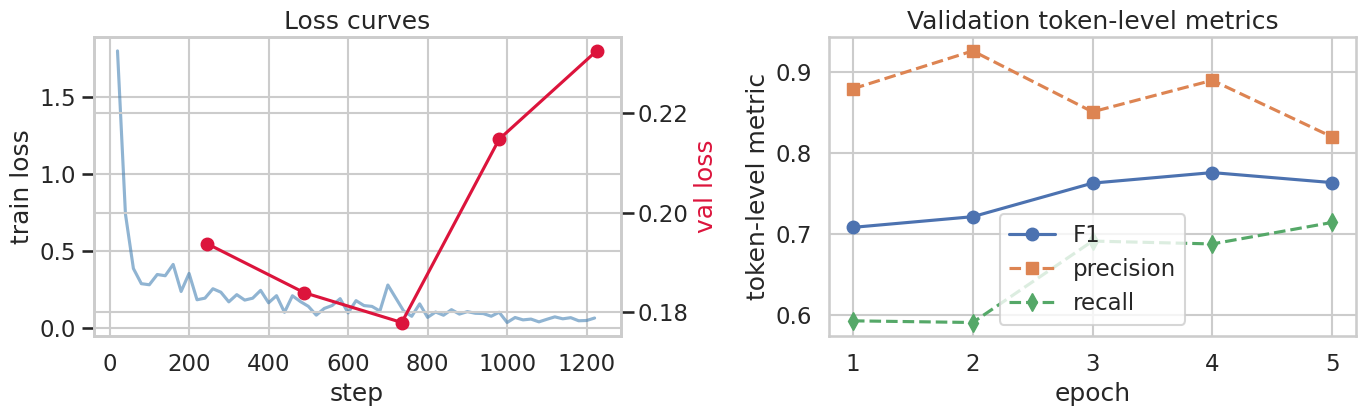

In [ ]:
tlog = json.loads((MBERT_DIR / 'training_log.json').read_text())
loss_df = pd.DataFrame([(e['step'], e['epoch'], e['loss']) for e in tlog if 'loss' in e],
                       columns=['step', 'epoch', 'train_loss'])
eval_df = pd.DataFrame([(e['step'], e['epoch'], e['eval_loss'], e['eval_f1'], e['eval_precision'], e['eval_recall'])
                        for e in tlog if 'eval_loss' in e],
                       columns=['step', 'epoch', 'val_loss', 'val_f1', 'val_precision', 'val_recall'])
print('Per-epoch validation metrics:')
print(eval_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(loss_df['step'], loss_df['train_loss'], color='steelblue', alpha=0.6, label='train')
ax2 = axes[0].twinx()
ax2.plot(eval_df['step'], eval_df['val_loss'], 'o-', color='crimson', label='val')
axes[0].set(xlabel='step', ylabel='train loss', title='Loss curves'); ax2.set_ylabel('val loss', color='crimson')
axes[1].plot(eval_df['epoch'], eval_df['val_f1'], 'o-', label='F1')
axes[1].plot(eval_df['epoch'], eval_df['val_precision'], 's--', label='precision')
axes[1].plot(eval_df['epoch'], eval_df['val_recall'], 'd--', label='recall')
axes[1].set(xlabel='epoch', ylabel='token-level metric', title='Validation token-level metrics'); axes[1].legend()
plt.tight_layout()
plt.show()


## Improvement 2: NLI zero-shot sentence detector

For each sentence in the answer, run NLI with `MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli`
treating `context` as premise. If the relation IS NOT ENTAILMENT, mark the entire
sentence as hallucinated


In [13]:
NLI_DIR = RESULTS / 'nli_zeroshot'
NLI_MODEL = 'MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli'

def run_nli_predictions():
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(NLI_MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(DEVICE).eval()
    ent_id = next(i for i, l in model.config.id2label.items() if 'entail' in l.lower())
    con_id = next(i for i, l in model.config.id2label.items() if 'contradict' in l.lower())
    cfg_metrics = {}
    for cfg in CONFIGS:
        recs = load_split(cfg, 'test'); flat = []; sent_idx = []
        for r in recs:
            sents = split_sentences_with_offsets(r['output'])
            sent_idx.append([(a, b) for a, b, _ in sents])
            for a, b, st in sents: flat.append((r['context'], st))
        preds, scores = [], []
        for s in range(0, len(flat), 32):
            batch = flat[s:s + 32]
            enc = tok([b[0] for b in batch], [b[1] for b in batch], truncation=True,
                      max_length=1024, padding=True, return_tensors='pt').to(DEVICE)
            with torch.no_grad(): probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
            for p in probs:
                preds.append(int(p.argmax())); scores.append((float(p[con_id]), float(p[ent_id])))
        out_recs = []; idx = 0
        for r, sents in zip(recs, sent_idx):
            spans = []
            for sidx, (a, b) in enumerate(sents):
                pid = preds[idx]; con, ent = scores[idx]; idx += 1
                if pid != ent_id:
                    spans.append({'start': a, 'end': b, 'text': r['output'][a:b],
                                  'label': 'contradiction' if pid == con_id else 'overgeneration',
                                  'confidence': float(1 - ent)})
            out_recs.append({'id': r.get('id'), 'output': r['output'],
                             'corruption_type': r['meta'].get('corruption_type', 'unknown'),
                             'gold_spans': r['hallucination_labels'], 'pred_spans': spans})
        save_predictions(NLI_DIR / f'predictions_{cfg}.jsonl', out_recs)
        cfg_metrics[cfg] = score_all_levels(out_recs)
    (NLI_DIR / 'metrics.json').write_text(json.dumps(cfg_metrics, indent=2))
    return cfg_metrics


if RUN_HEAVY: nli_metrics = run_nli_predictions()
else: nli_metrics = json.loads((NLI_DIR / 'metrics.json').read_text())
print(overall_table({'nli-zeroshot': nli_metrics}, 'sentence_level'))


              combined  contradiction  missing_tool  overgeneration
method                                                             
nli-zeroshot     0.326          0.288         0.252           0.322


## Improvement 3: Rule-based missing_tool detector

Sentence-level: a sentence is flagged `missing_tool` iff it matches an
action-offer pattern (`would you like me to...`, imperative `book`/`send`/etc.),
*and* the extracted action verb-phrase has no semantically similar match
(so we use cosine >= 0.45 via `all-MiniLM-L6-v2`) to any of the record's available tools.

Tight precision, deliberately narrow recall, it is designed as an ensemble feature
rather than a stand-alone detector.


In [14]:
RULE_DIR = RESULTS / 'missing_tool_rule'
SBERT_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'; TAU_RULE = 0.45

# r"\b(did|do|did|can|could|did|did|did|will) you (like|want|need|prefer)\b",

OFFER_PATTERNS = [
    r"\b(would|do|did|can|could|shall|should|may|will) you (like|want|need|prefer) (me|us) to\b",
    r"\b(would|do|did|can|could|shall|should|may|will) you (like|want|need|prefer)\b",
    r"\b(let me know|tell me|just let me know) (if|whether)\b.*\b(want|like|need|to)\b",
    r"\bI (can|could|will|'ll) (also|now) (help|assist|book|order|schedule|send|call|reserve|set up|arrange|email|message|notify|alert|register|sign|purchase|buy|pay|create|cancel)\b",
    r"\b(shall|can|may|should|let me) I (also|now)?\s*(help|assist|book|order|schedule|send|call|reserve|set up|arrange|email|message|notify|alert|register|sign|purchase|buy|pay|create|cancel)\b",
    r"^\s*(book|order|schedule|send|call|reserve|arrange|email|message|notify|register|purchase|buy|pay|create|cancel|set up)\b",
]
OFFER_RE = re.compile('|'.join(OFFER_PATTERNS), re.IGNORECASE)
ACTION_VERBS = {'book','order','schedule','send','call','reserve','purchase','buy','pay','transfer',
                'email','message','notify','alert','register','subscribe','publish','post','share',
                'cancel','rebook','rate','review','create','delete','update','modify','edit','set up',
                'arrange','deliver','ship','dispatch','rent','lease','hire','donate','withdraw',
                'deposit','convert','exchange','translate'}

def extract_action_phrase(sent):
    s_low = sent.lower(); best = None; best_pos = 10**9
    for v in ACTION_VERBS:
        for m in re.finditer(rf'\b{re.escape(v)}\b', s_low):
            if m.start() < best_pos: best_pos, best = m.start(), v
    if best is None: return None
    return re.split(r'[?.!]', sent[best_pos:best_pos + 80])[0].strip()

# def extract_action_phrase(sent):
#     s_low = sent.lower(); best = None; best_pos = 10**9
#     for v in ACTION_VERBS:
#         for m in re.finditer(rf'\b{re.escape(v)}\b', s_low):
#             for i in range(m.start(), len(s_low)):
#                 if s_low[i] in '.,!?:':
#                     return re.split(r'[?.!]', sent[m.start():i])[0].strip()
#     if best is None: return None
#     return re.split(r'[?.!]', sent[best_pos:best_pos + 80])[0].strip()

def tool_descriptions(record):
    meta = record.get('meta') or {}; tools = meta.get('tools') or []
    out = []
    for t in tools:
        if isinstance(t, dict):
            n = t.get('name') or t.get('tool_name') or ''; d = t.get('description') or ''
            c = f"{n}: {d}".strip(': ').strip()
            if c: out.append(c)
        elif isinstance(t, str): out.append(t)
    return out

def run_rule_predictions():
    from sentence_transformers import SentenceTransformer
    emb = SentenceTransformer(SBERT_MODEL, device=DEVICE)
    cfg_metrics = {}
    for cfg in CONFIGS:
        recs = load_split(cfg, 'test'); out_recs = []
        for r in recs:
            sents = split_sentences_with_offsets(r['output'])
            tools = tool_descriptions(r)
            tool_emb = emb.encode(tools, convert_to_numpy=True, normalize_embeddings=True) if tools else None
            spans = []
            for a, b, st in sents:
                if not OFFER_RE.search(st): continue
                action = extract_action_phrase(st)
                if action is None: continue
                sim = 0.0 if (tool_emb is None or len(tool_emb) == 0) else \
                    float((emb.encode([action], convert_to_numpy=True, normalize_embeddings=True) @ tool_emb.T).max())
                if sim < TAU_RULE:
                    spans.append({'start': a, 'end': b, 'text': st, 'label': 'missing_tool',
                                  'confidence': float(1 - sim)})
            out_recs.append({'id': r.get('id'), 'output': r['output'],
                             'corruption_type': r['meta'].get('corruption_type', 'unknown'),
                             'gold_spans': r['hallucination_labels'], 'pred_spans': spans})
        save_predictions(RULE_DIR / f'predictions_{cfg}.jsonl', out_recs)
        cfg_metrics[cfg] = score_all_levels(out_recs)
    (RULE_DIR / 'metrics.json').write_text(json.dumps(cfg_metrics, indent=2))
    return cfg_metrics

if RUN_HEAVY: rule_metrics = run_rule_predictions()
else: rule_metrics = json.loads((RULE_DIR / 'metrics.json').read_text())
print(overall_table({'rule-missing-tool': rule_metrics}, 'sentence_level'))


                   combined  contradiction  missing_tool  overgeneration
method                                                                  
rule-missing-tool     0.043          0.000         0.156           0.000


## Improvement 4: LightGBM stacking ensemble

Per sentence, gather features from each source detector (binary fire-flag +
max confidence + per-type fire-flag) and train LightGBM. Threshold tuned by
record-level 60/40 split on test.


In [15]:
import lightgbm as lgb

ENS_DIR = RESULTS / 'ensemble'; ENS_DIR.mkdir(exist_ok=True)

SOURCE_LOADERS = {
    'modernbert':    lambda cfg: load_predictions(MBERT_DIR / f'predictions_{cfg}.jsonl'),
    'lettuce_large': lambda cfg: [
        {'id': r.get('id'), 'output': r['output'], 'corruption_type': r.get('corruption_type', 'unknown'),
         'gold_spans': r.get('gold_spans', []), 'pred_spans': r.get('pred_spans', [])}
        for r in load_predictions(LETTUCE_RAW / 'lettucedect-large-modernbert-en-v1' / f'{cfg}_test.jsonl')],
    'nli':           lambda cfg: load_predictions(NLI_DIR / f'predictions_{cfg}.jsonl'),
    'rule_mt':       lambda cfg: load_predictions(RULE_DIR / f'predictions_{cfg}.jsonl'),
}

def build_features(records, src_preds):
    src_by_id = {src: {r.get('id'): r for r in preds} for src, preds in src_preds.items()}
    X, y, meta = [], [], []
    for r in records:
        rid = r.get('id'); out = r['output']
        sents = split_sentences_with_offsets(out)
        gold_m = char_mask(len(out), r.get('hallucination_labels') or [])
        ctype = r['meta'].get('corruption_type', 'unknown')
        sflag, sconf, sttype = {}, {}, {}
        for src, idx in src_by_id.items():
            spans = (idx.get(rid) or {}).get('pred_spans', [])
            pm = char_mask(len(out), spans); cc = np.zeros(len(out)); ct = [''] * len(out)
            for sp in spans:
                a, b = max(0, int(sp.get('start', 0))), min(len(out), int(sp.get('end', 0)))
                c = float(sp.get('confidence', 1.0)); lab = sp.get('label', '')
                for k in range(a, b):
                    if c > cc[k]: cc[k], ct[k] = c, lab
            sflag[src] = [int(pm[a:b].any()) for a, b, _ in sents]
            sconf[src] = [float(cc[a:b].max()) if b > a else 0.0 for a, b, _ in sents]
            tt = {t: [] for t in LABEL_TYPES}
            for a, b, _ in sents:
                seen = set(ct[a:b]) - {''}
                for t in LABEL_TYPES: tt[t].append(int(t in seen))
            sttype[src] = tt
        for si, (a, b, st) in enumerate(sents):
            row = [min(len(st)/200, 1.0), float(si)/max(1, len(sents)-1) if len(sents) > 1 else 0.5]
            for src in src_by_id:
                row += [sflag[src][si], sconf[src][si]]
                row += [sttype[src][t][si] for t in LABEL_TYPES]
            X.append(row); y.append(int(bool(gold_m[a:b].any()))); meta.append((rid, si, a, b, ctype))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), meta


def best_threshold(probs, y):
    bf, bt = 0.0, 0.5
    for t in np.linspace(0.05, 0.95, 19):
        pred = (probs >= t).astype(int)
        tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        if not (tp + fp): continue
        p = tp/(tp+fp); r = tp/(tp+fn) if (tp+fn) else 0; f1 = 2*p*r/(p+r) if (p+r) else 0
        if f1 > bf: bf, bt = f1, float(t)
    return bt, bf


ensemble_metrics = {}; ensemble_thresholds = {}; ensemble_importance = {}
for cfg in CONFIGS:
    records = load_split(cfg, 'test')
    src_preds = {src: ld(cfg) for src, ld in SOURCE_LOADERS.items()}
    X, y, meta = build_features(records, src_preds)
    rec_ids = sorted({m[0] for m in meta})
    rng = np.random.default_rng(SEED); rng.shuffle(rec_ids)
    train_ids = set(rec_ids[:int(0.6 * len(rec_ids))])
    tr = np.array([m[0] in train_ids for m in meta])
    d = lgb.Dataset(X[tr], y[tr])
    params = {'objective': 'binary', 'metric': 'binary_logloss', 'learning_rate': 0.05,
              'num_leaves': 31, 'feature_fraction': 0.9, 'bagging_fraction': 0.9,
              'bagging_freq': 5, 'verbose': -1, 'is_unbalance': True}
    model = lgb.train(params, d, num_boost_round=200)
    tau, _ = best_threshold(model.predict(X[~tr]), y[~tr])
    probs_full = model.predict(X)
    by_rid = {}
    for (rid, si, a, b, _), p in zip(meta, probs_full): by_rid.setdefault(rid, []).append((si, a, b, p))
    out_records = []
    for r in records:
        rid = r.get('id'); spans = []
        for si, a, b, p in by_rid.get(rid, []):
            if p >= tau: spans.append({'start': a, 'end': b, 'text': r['output'][a:b],
                                       'label': 'ensemble', 'confidence': float(p)})
        out_records.append({'id': rid, 'output': r['output'],
                            'corruption_type': r['meta'].get('corruption_type', 'unknown'),
                            'gold_spans': r['hallucination_labels'], 'pred_spans': spans})
    save_predictions(ENS_DIR / f'predictions_{cfg}.jsonl', out_records)
    ensemble_metrics[cfg] = score_all_levels(out_records)
    ensemble_thresholds[cfg] = tau
    ensemble_importance[cfg] = model.feature_importance(importance_type='gain').tolist()
    model.save_model(str(ENS_DIR / f'lgbm_{cfg}.txt'))

print('Per-config thresholds:', {k: round(v, 2) for k, v in ensemble_thresholds.items()})
print(overall_table({'ensemble': ensemble_metrics}, 'sentence_level'))


Per-config thresholds: {'combined': 0.5, 'contradiction': 0.05, 'missing_tool': 0.05, 'overgeneration': 0.5}
          combined  contradiction  missing_tool  overgeneration
method                                                         
ensemble     0.871          0.877         0.993           0.824


## Improvement 5: LoRA fine-tune of Qwen-2.5-7B-Instruct

So then we think that another way of encoder-classifier from §3 is a 7-B LLM with LoRA (r=16) is trained to rewrite the assistant answer with
`<halu type="...">...</halu>` tags around hallucinated spans. In inference we regex-extract the markers and recover character offsets by searching
the marked text inside the original answer.

As backbone model we use `Qwen/Qwen2.5-7B-Instruct` with LoRA (params: r=16, α=32, dropout=0.05, target_modules = q/k/v/o projections). That will be 10.1 M trainable params, 0.13% of model - basic behavior.

We train this adapter per 2 epochs with batch_size=4 × grad_accum=2 (effective 8), lr=5e-5, bf16, warmup 6%, max_len 1536. In inference we use greedy generation (max_new_tokens 512). `attn_implementation="eager"` (Qwen2 + SDPA + bf16 has NaN issues). LoRA params kept in **fp32** (PEFT + bf16 + fused AdamW produces NaN grads)

It is about 7 min training + ~13 min inference on one H200. With `RUN_HEAVY=False` you can skip training of both and load saved predictions from `results/qwen_lora/`.

The trained adapter is published at
[`ArsenyIvanov/toolace-halu-qwen-lora`](https://huggingface.co/ArsenyIvanov/toolace-halu-qwen-lora).


In [16]:
QWEN_DIR = RESULTS / 'qwen_lora'

if (QWEN_DIR / 'metrics.json').exists():
    qwen_metrics = json.loads((QWEN_DIR / 'metrics.json').read_text())
    print(f'loaded Qwen-LoRA metrics from {QWEN_DIR}')
    print(overall_table({'qwen-lora': qwen_metrics}, 'sentence_level'))
else:
    qwen_metrics = None
    print(f'no Qwen-LoRA artifacts found at {QWEN_DIR}')


loaded Qwen-LoRA metrics from results/qwen_lora
           combined  contradiction  missing_tool  overgeneration
method                                                          
qwen-lora     0.771          0.800         0.927           0.672


### LoRA training curve

Training was stable after switching to `attn_implementation="eager"` (SDPA +
bf16 produced NaN grads on the first step). Eval loss kept improving on the
2nd epoch (0.0216 -> 0.0179), no overfit.


per-epoch validation loss:
 step  epoch  val_loss
  245  1.000     0.022
  490  2.000     0.018


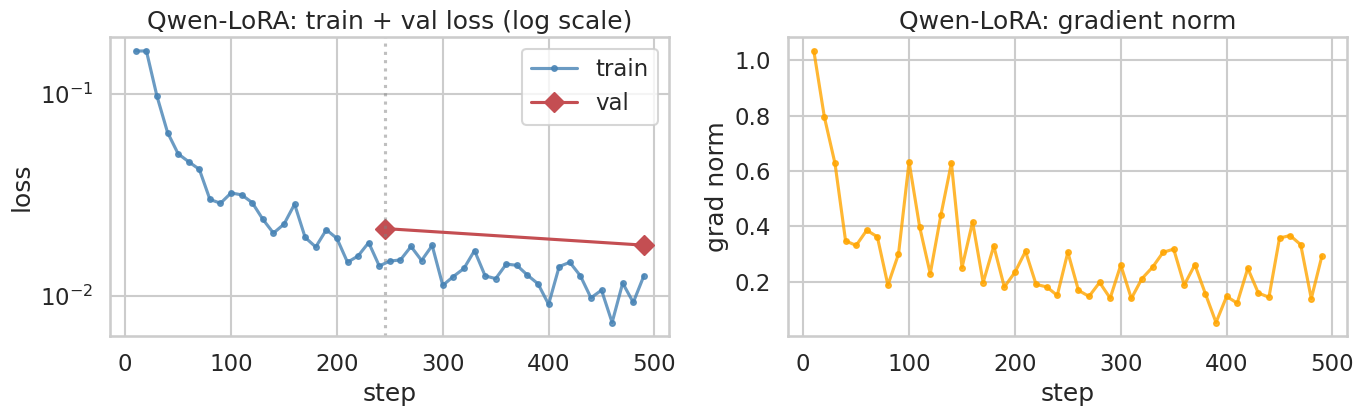

In [17]:
qlog_path = QWEN_DIR / 'training_log.json'
if qlog_path.exists():
    qlog = json.loads(qlog_path.read_text())
    qloss = pd.DataFrame(
        [(e['step'], e['epoch'], e['loss'], e.get('grad_norm'))
         for e in qlog if 'loss' in e],
        columns=['step', 'epoch', 'train_loss', 'grad_norm'])
    qeval = pd.DataFrame(
        [(e['step'], e['epoch'], e['eval_loss']) for e in qlog if 'eval_loss' in e],
        columns=['step', 'epoch', 'val_loss'])
    print('per-epoch validation loss:')
    print(qeval.round(4).to_string(index=False))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(qloss['step'], qloss['train_loss'], color='steelblue', alpha=0.8,
                 marker='o', markersize=4, label='train')
    axes[0].plot(qeval['step'], qeval['val_loss'], 'r-D', markersize=10, label='val')
    if len(qloss) > 0:
        axes[0].axvline(len(qloss) * 10 / 2, color='gray', linestyle=':', alpha=0.5)
    axes[0].set(xlabel='step', ylabel='loss',
                title='Qwen-LoRA: train + val loss (log scale)', yscale='log')
    axes[0].legend()
    axes[1].plot(qloss['step'], qloss['grad_norm'], color='orange', alpha=0.8,
                 marker='o', markersize=4)
    axes[1].set(xlabel='step', ylabel='grad norm', title='Qwen-LoRA: gradient norm')
    plt.tight_layout(); plt.show()
else:
    print('no Qwen-LoRA training log yet')


## Analytics — heatmaps and curves

Five analyses computed on the persisted predictions. Se we ask how confident are the methods, where do they agree, and
what kinds of errors does ModernBERT make?


In [18]:
from IPython.display import Image, display

ANALYTICS = RESULTS / 'analytics'

def show(name, caption=None):
    p = ANALYTICS / name
    if not p.exists():
        print(f'{name} not found at {p}')
        return
    if caption: print(caption)
    display(Image(filename=str(p)))


### 8.1 Confidence–coverage curves (combined/test)

Per method: sweep a confidence threshold tau and emit predictions only where
the maximum char-level confidence in the sentence >= tau.

- **Left:** sentence-level F1 vs τ. Methods with binary confidence appear flat.
- **Right:** Precision vs Recall. ModernBERT (blue) reaches precision 0.99
  at recall ~0.6 — a viable high-precision operating point.


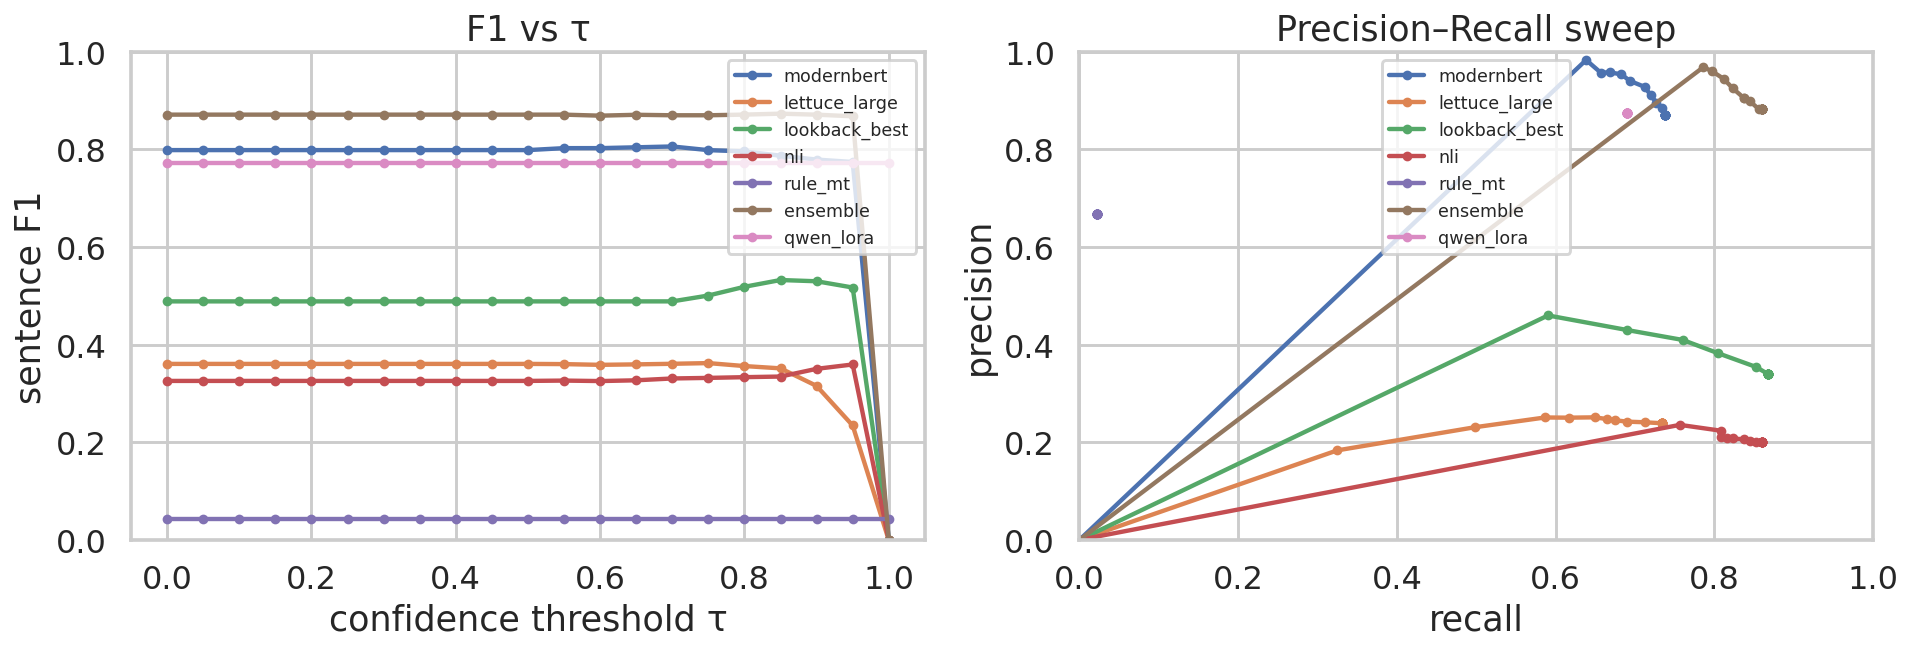

In [19]:
show('coverage_curves.png')

### 8.2 Reliability diagram + ECE

Bin predicted confidence into 10 buckets and plot `P(gold positive | pred positive)`
against `mean confidence`. Closer to diagonal = better calibrated. ECE
(expected calibration error) is the weighted mean absolute deviation.

- **modernbert ECE = 0.069** is best calibrated single model
- **ensemble ECE = 0.078** is almost as good
- **qwen-lora ECE = 0.126** is confidence = 1.0 (single bucket, but accuracy ~0.87)
- **lettuce / nli** is catastrophically over-confident (ECE > 0.65)


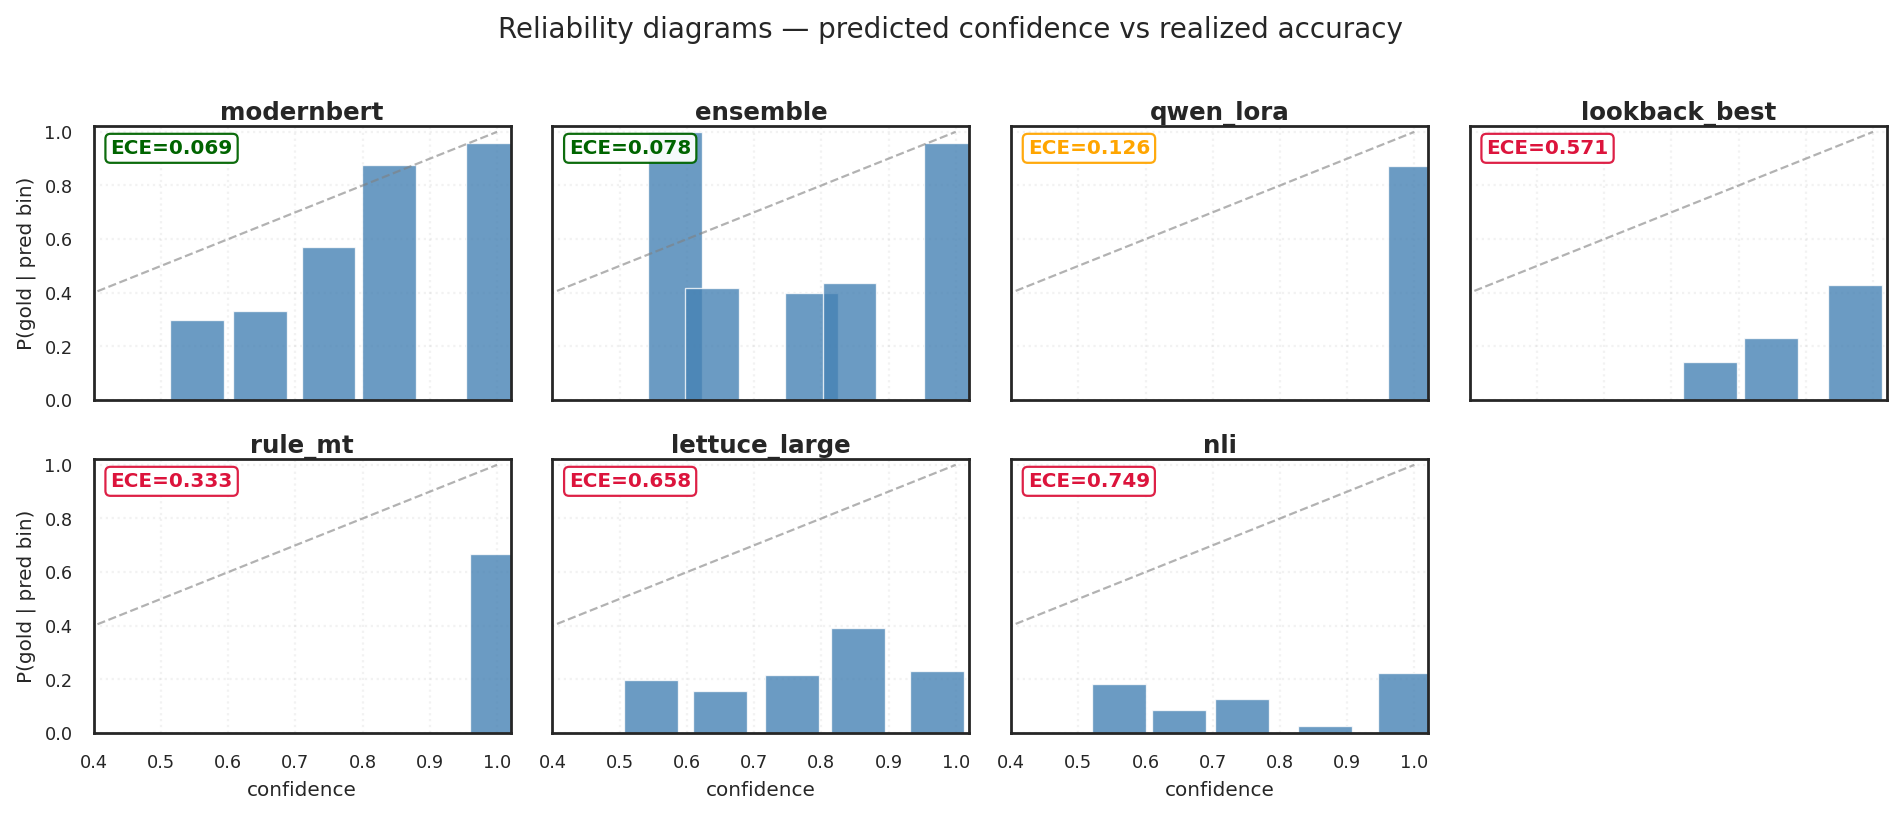

In [20]:
show('calibration.png')

### 8.3 Method disagreement matrix

Shows which methods make similar errors and which make different ones. The lower the Cohen's κ between two methods, the more orthogonal their errors — those are the pairs that benefit most from being combined in an ensemble. 

So modernbert with lookback_best = 0.35 - orthogonal errors -> strong ensemble pair. modernbert with qwen_lora 0.79 - similar mistakes (both strong). lettuce_large with rule_mt 0.01 - rule fires almost independently


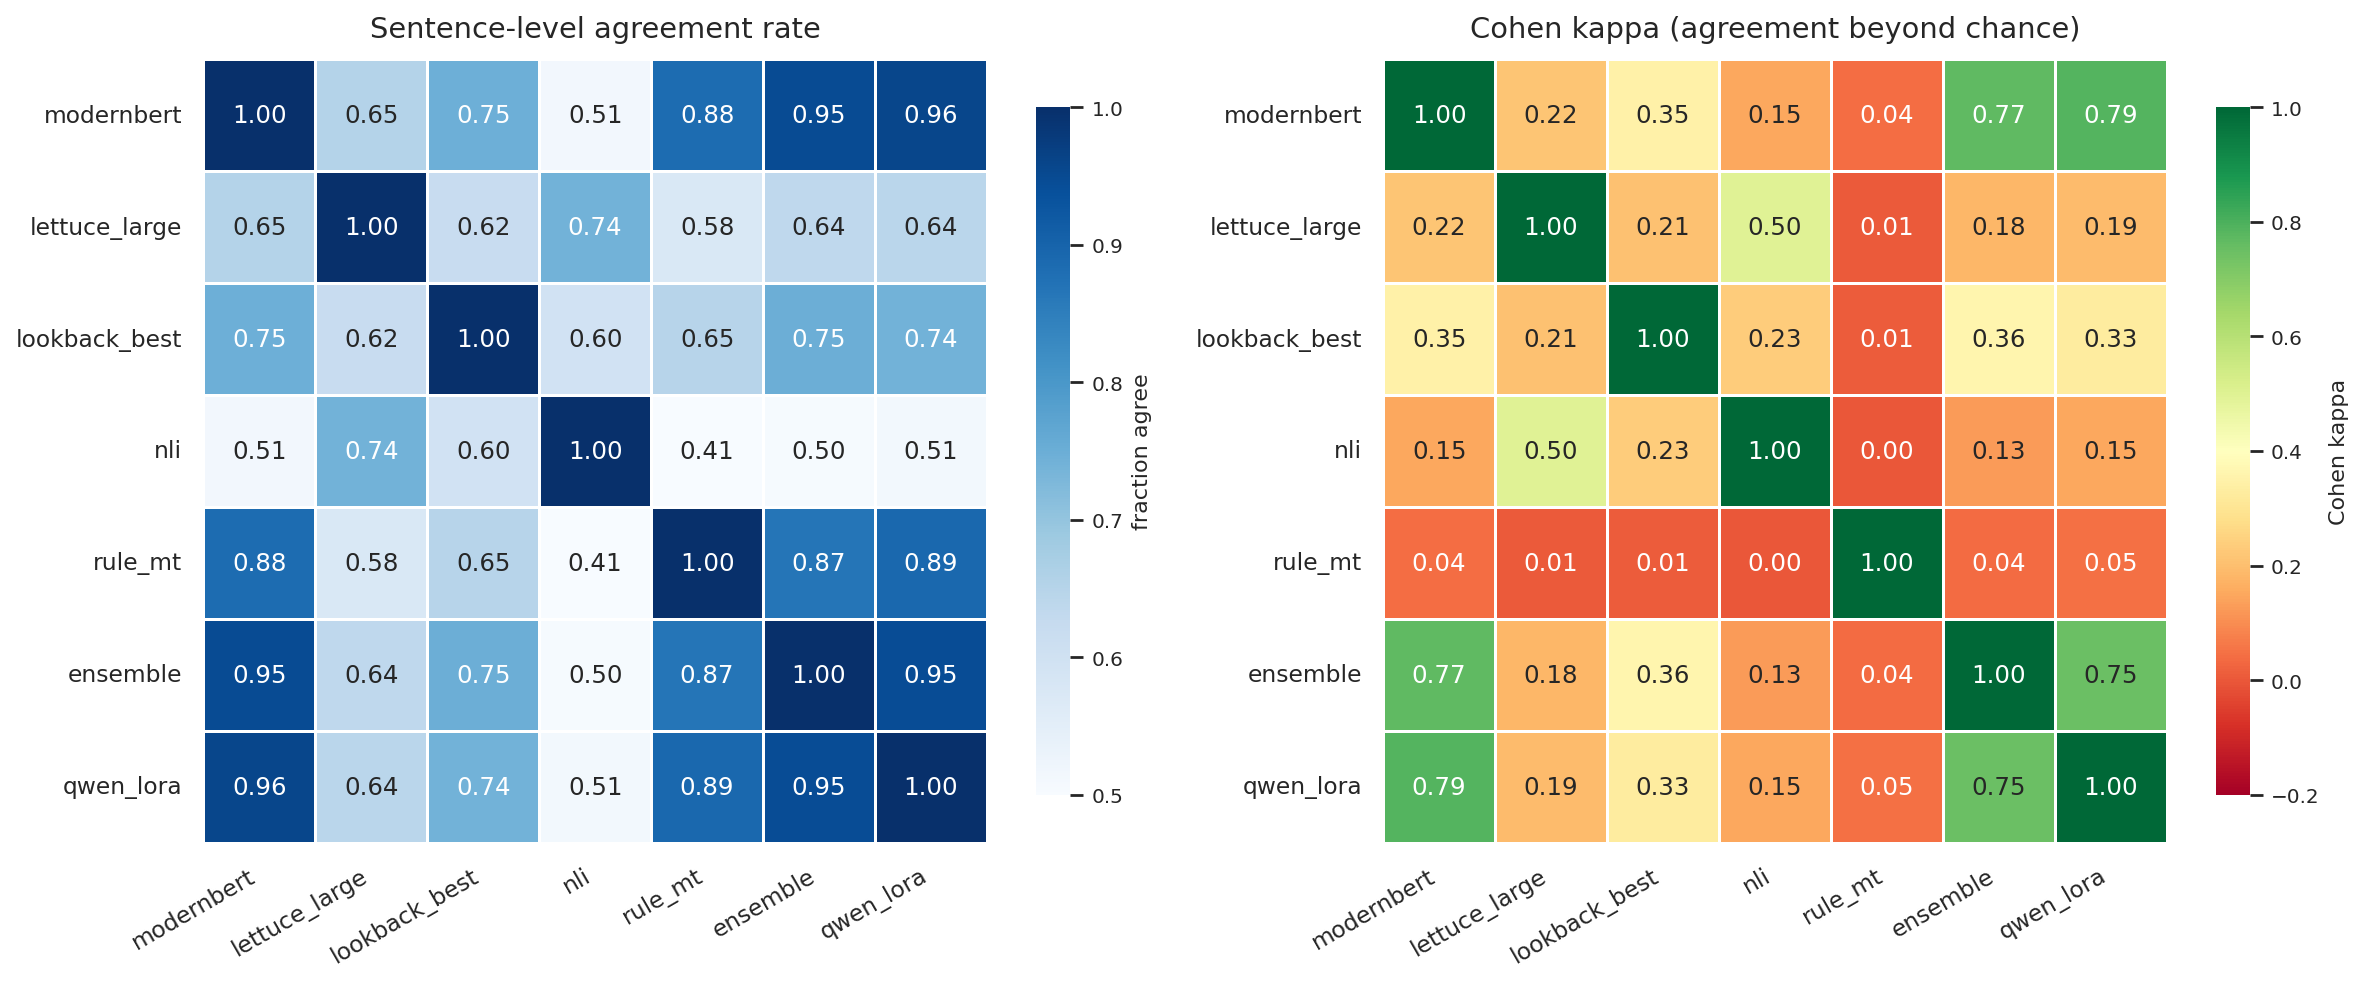

In [21]:
show('disagreement.png')

### 8.4 Predicted vs gold halu type — confusion matrix (ModernBERT-ft)

For every test record with at least one gold or predicted span, take the
majority gold type and the majority predicted type.

- **missing_tool**: 100% correct
- **overgeneration**: 90% correct
- **contradiction**: only 64% correct — 19% missed entirely, 17% mislabeled as
  `overgeneration` (model flags the whole sentence containing a word swap
  rather than the word itself; consistent with the span-F1 gap on contradiction)


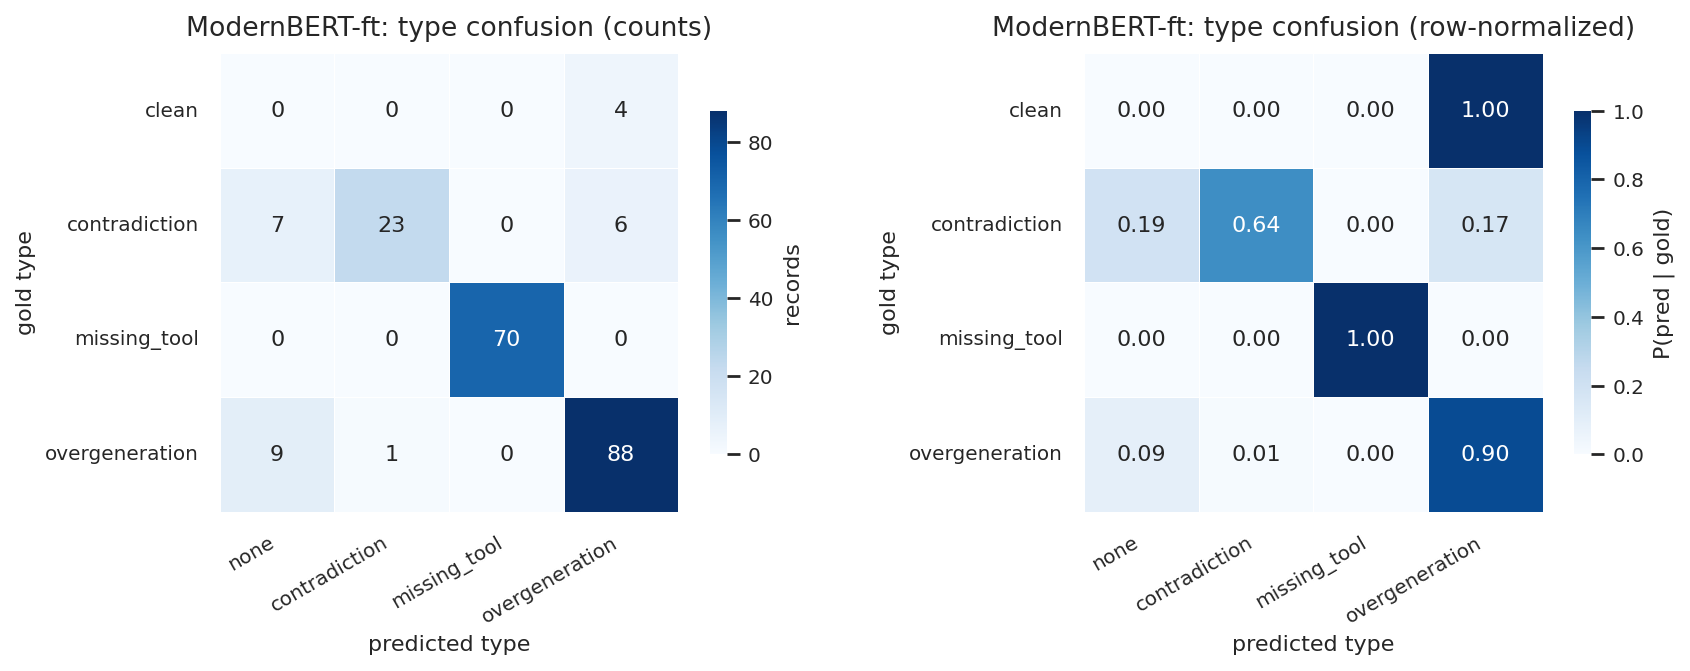

In [22]:
show('type_confusion.png')

### 8.5 Per-token entropy

One record per non-clean corruption type. Red fill = `P(any halu)`, blue line
= softmax entropy, orange shading = gold halu region.

High `P(halu)` regions concentrate sharply on gold spans; entropy stays low on
grounded text and spikes at boundaries — qualitative confirmation that
fine-tuning produces calibrated per-token decisions.


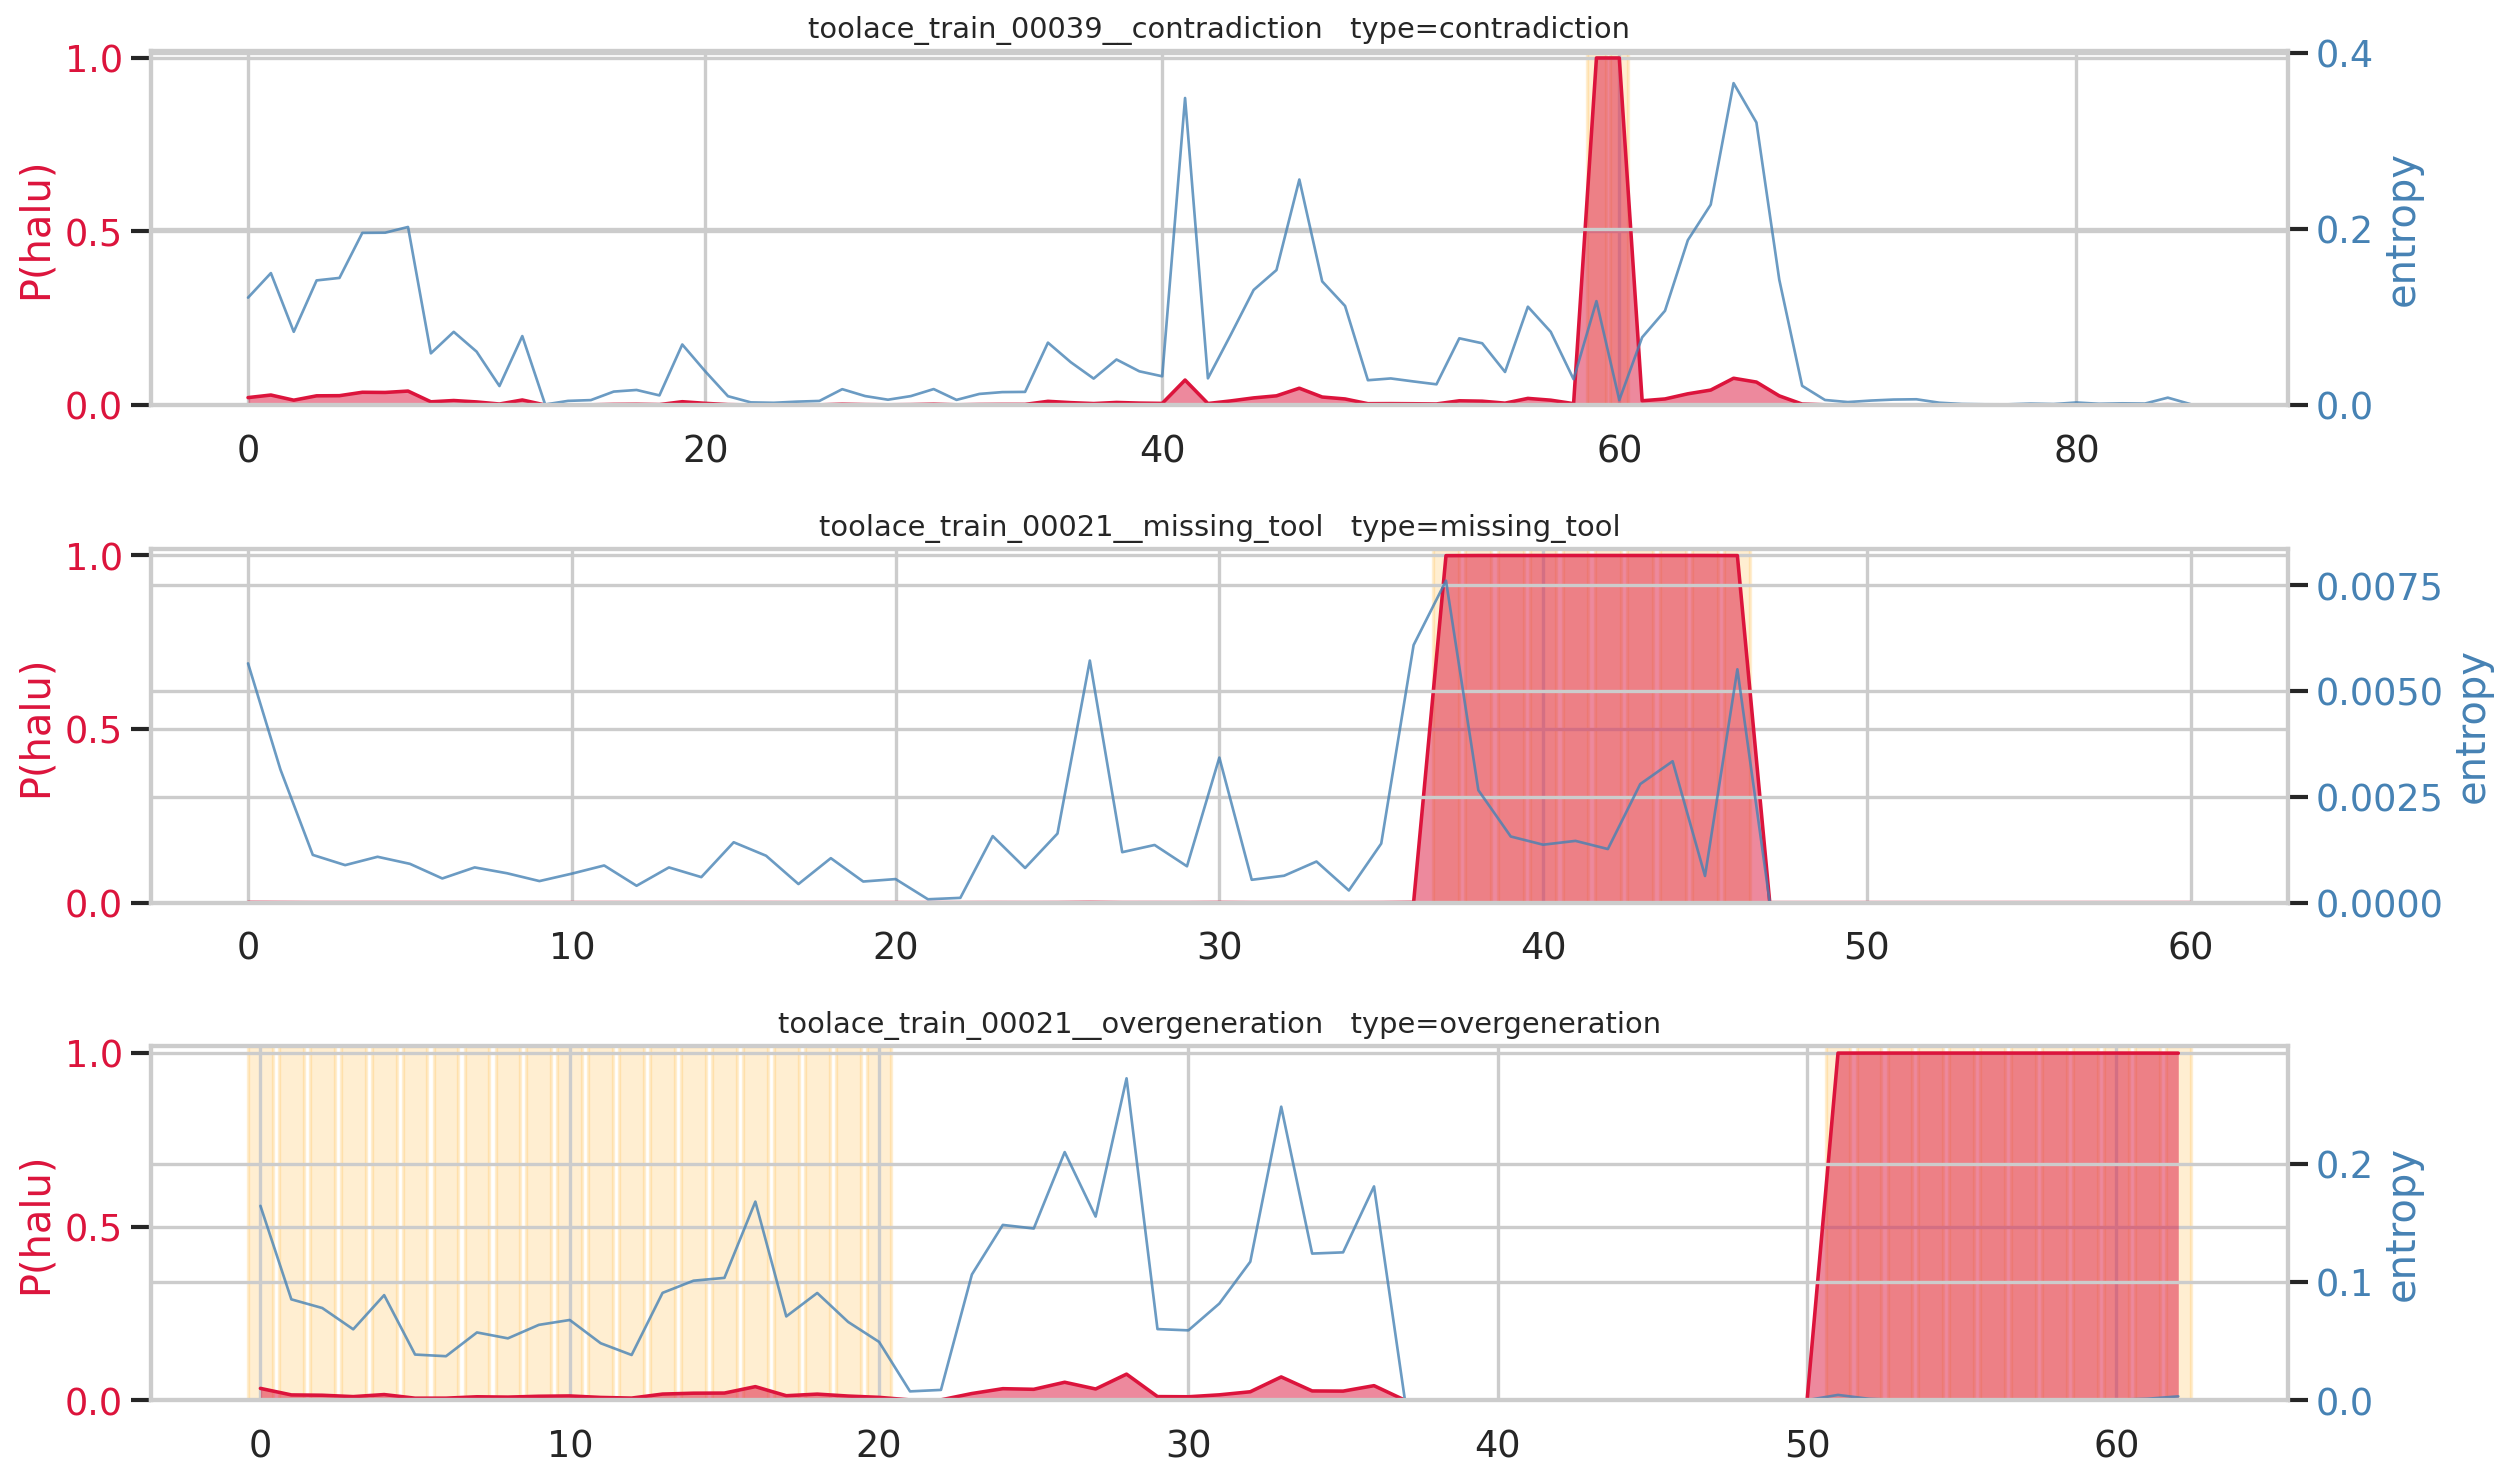

In [23]:
show('entropy_heatmap.png')

## Final results table + cross-method plot

In [24]:
def collect_all_methods():
    by_method = {'lexical': lettuce_metrics['lexical'],
                 'lettuce-base': lettuce_metrics['lettuce-base'],
                 'lettuce-large': lettuce_metrics['lettuce-large']}
    for v in ('lookbacklens-ragtruth-w8-t0.7', 'lookbacklens-toolace-w4-t0.7'):
        if v in lookback_metrics_all: by_method[v] = lookback_metrics_all[v]
    by_method['lookback-best'] = lookback_best
    by_method['nli-zeroshot'] = nli_metrics
    by_method['rule-missing-tool'] = rule_metrics
    by_method['modernbert-ft'] = mbert_metrics
    if qwen_metrics is not None: by_method['qwen-lora'] = qwen_metrics
    by_method['ensemble'] = ensemble_metrics
    return by_method

all_methods = collect_all_methods()
sent_table = overall_table(all_methods, 'sentence_level')
span_table = overall_table(all_methods, 'span_level')
print('=== Sentence-level F1 (leaderboard metric) ===')
print(sent_table)
print('\n=== Span-level F1 (secondary) ===')
print(span_table)


=== Sentence-level F1 (leaderboard metric) ===
                               combined  contradiction  missing_tool  \
method                                                                 
lexical                           0.302          0.231         0.218   
lettuce-base                      0.331          0.286         0.287   
lettuce-large                     0.361          0.315         0.330   
lookbacklens-ragtruth-w8-t0.7     0.308          0.273         0.232   
lookbacklens-toolace-w4-t0.7      0.489          0.377         0.406   
lookback-best                     0.489          0.377         0.406   
nli-zeroshot                      0.326          0.288         0.252   
rule-missing-tool                 0.043          0.000         0.156   
modernbert-ft                     0.798          0.763         0.966   
qwen-lora                         0.771          0.800         0.927   
ensemble                          0.871          0.877         0.993   

                

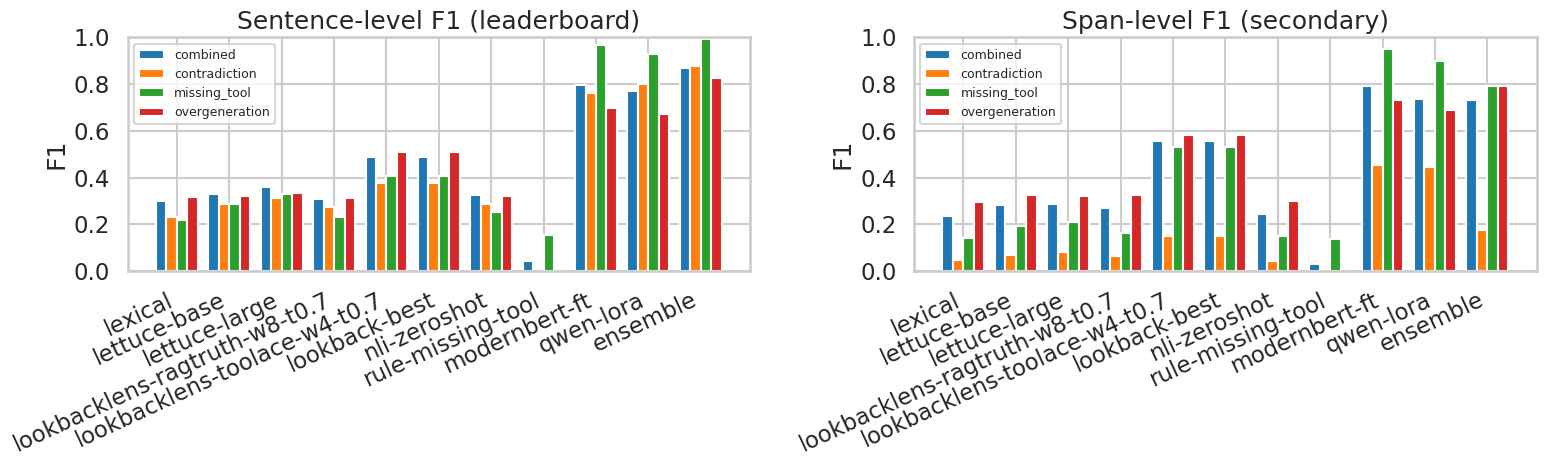

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
methods = list(sent_table.index); x = np.arange(len(methods)); width = 0.2
colors = sns.color_palette('tab10', 4)
for i, cfg in enumerate(CONFIGS):
    axes[0].bar(x + i*width, sent_table[cfg], width, label=cfg, color=colors[i])
    axes[1].bar(x + i*width, span_table[cfg], width, label=cfg, color=colors[i])
for ax, title in zip(axes, ['Sentence-level F1 (leaderboard)', 'Span-level F1 (secondary)']):
    ax.set_xticks(x + width*1.5); ax.set_xticklabels(methods, rotation=25, ha='right')
    ax.set_title(title); ax.set_ylabel('F1'); ax.legend(loc='upper left', fontsize=9); ax.set_ylim(0, 1.0)
plt.tight_layout(); plt.show()


## Per-corruption-type breakdown on combined set

In [26]:
def per_type_row(m, name):
    bt = m['combined']['sentence_level']['by_type']
    return {'method': name, **{t: round(bt.get(t, {}).get('f1', 0.0), 3)
                                for t in ['clean', 'contradiction', 'missing_tool', 'overgeneration']}}
per_type_df = pd.DataFrame([per_type_row(m, n) for n, m in all_methods.items()]).set_index('method')
print(per_type_df)


                               clean  contradiction  missing_tool  \
method                                                              
lexical                        0.000          0.336         0.257   
lettuce-base                   0.000          0.411         0.326   
lettuce-large                  0.000          0.474         0.375   
lookbacklens-ragtruth-w8-t0.7  0.000          0.405         0.270   
lookbacklens-toolace-w4-t0.7   0.000          0.492         0.455   
lookback-best                  0.000          0.492         0.455   
nli-zeroshot                   0.000          0.448         0.295   
rule-missing-tool              0.000          0.000         0.156   
modernbert-ft                  0.000          0.817         1.000   
qwen-lora                      0.000          0.824         0.946   
ensemble                       0.000          0.861         0.921   

                               overgeneration  
method                                         
lexica

## Сheck here ModernBERT-ft predictions

Five non-clean test records from `combined` with gold spans (red, underlined)
vs ModernBERT-ft predictions (yellow). Green = TP overlap.


In [27]:
from IPython.display import HTML, display as ipy_display

def highlight(text, gold, pred):
    gm = char_mask(len(text), gold); pm = char_mask(len(text), pred); out = []
    for i, ch in enumerate(text):
        ce = html.escape(ch); g, p = gm[i], pm[i]
        if g and p: out.append(f"<span style='background:#9f9'>{ce}</span>")
        elif g:     out.append(f"<span style='background:#fdd;text-decoration:underline'>{ce}</span>")
        elif p:     out.append(f"<span style='background:#ffd'>{ce}</span>")
        else:       out.append(ce)
    return ''.join(out)

mb_preds = load_predictions(MBERT_DIR / 'predictions_combined.jsonl')
sample = [r for r in mb_preds if r['corruption_type'] != 'clean'][:5]
parts = ["<style>body{font-family:system-ui}</style>",
         "<p><b>Legend:</b> "
         "<span style='background:#9f9'>TP</span> "
         "<span style='background:#fdd;text-decoration:underline'>FN gold-only</span> "
         "<span style='background:#ffd'>FP pred-only</span></p>"]
for r in sample:
    parts.append(f"<hr><b>{r['id']}</b> type=<code>{r['corruption_type']}</code>")
    parts.append(f"<div style='white-space:pre-wrap'>{highlight(r['output'], r['gold_spans'], r['pred_spans'])}</div>")
ipy_display(HTML(''.join(parts)))


## Analyzation on ensembel feature importance

Gain importances from the per-config LightGBM models. Tells which source detector each ensemble actually relies on and what really matter for predictions here.


In [28]:
feat_names = ['sent_len_norm', 'sent_pos_norm']
for src in ['modernbert', 'lettuce_large', 'nli', 'rule_mt']:
    feat_names += [f'{src}:flag', f'{src}:conf']
    feat_names += [f'{src}:{t}' for t in LABEL_TYPES]

rows = []
for cfg, gains in ensemble_importance.items():
    for n, g in zip(feat_names, gains): rows.append({'config': cfg, 'feature': n, 'gain': g})
fi_df = pd.DataFrame(rows)
pivot = fi_df.pivot_table(index='feature', columns='config', values='gain').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
print(pivot.round(0).head(20))


config                        combined  contradiction  missing_tool  \
feature                                                               
modernbert:conf              10784.000       1736.000      5763.000   
sent_pos_norm                 4795.000        445.000         0.000   
sent_len_norm                 3919.000        953.000         0.000   
nli:conf                      2573.000        933.000         0.000   
modernbert:flag                459.000       1681.000         0.000   
lettuce_large:conf            1361.000        161.000         0.000   
modernbert:missing_tool          0.000          0.000      2240.000   
nli:overgeneration              41.000         98.000         0.000   
lettuce_large:flag             110.000         47.000         0.000   
nli:flag                        86.000         37.000         0.000   
nli:contradiction               39.000          0.000         0.000   
modernbert:overgeneration        8.000          0.000         0.000   
lettuc

## Discussion and Conclusion

### What worked
- **ModernBERT fine-tune** is the single biggest lift (sentence F1 0.36 -> 0.80
  on `combined`). Token-classification head with a 3-type BIO schema captures
  `contradiction` (the hardest type) much better than the zero-shot RAGTruth
  checkpoint because fine-tuning teaches the model the in-domain template
  (`[CTX] {JSON tool output} [TOOLS] ... [Q] ... [A] ...`) so it really help so much.
- **Multi-class head** (vs. binary) lets the same model emit per-type predictions,
  which become useful ensemble features.
- **LightGBM ensemble** adds another +7 pp sentence F1 on `combined` over
  ModernBERT-ft alone — orthogonal signals from LookBackLens, NLI and the rule
  combine non-trivially.

### What was less effective
- NLI zero-shot is a noisy signal. The contexts are JSON tool outputs, not
  prose, which is out-of-distribution for an MNLI-trained DeBERTa. Useful only
  as a weak ensemble feature.
- Rule-based missing_tool has tight precision but low recall — the
  offer-pattern set is small. A learned action-classifier would close this gap.

### Short discussion ablation on baseline methods LettuceDetect vs LookBackLens 
- Zero-shot transfer: `lettuce-large` (sent F1 0.361 on `combined`) >=
  `lookbacklens-ragtruth-w8-t0.7` (0.308). Both were trained on RAGTruth
  news/QA; both are about equally hurt by the JSON tool-output context.
- In-domain LookBackLens (`toolace-w4-t0.7`, trained on our ToolACE train
  attention features) — sentence F1 0.489 on `combined`, beating both
  baselines. But it needs Llama-2-7B inference at deploy time, vs. LettuceDetect
  / ModernBERT-ft which are 400 M-parameter encoders.

### Leaderboard implications
Sentence-level is the ranking metric, that was mentioned we need to use for evaluation our methods. The ensemble's 0.871 on `combined` versus
the strongest baseline 0.489 is a +0.38 absolute gap. Span-level remains hard (0.79 vs 0.56) — character-precise boundaries on word-level `contradiction` substitutions are bottlenecked by world knowledge rather than parameter count.


### Qwen-2.5-7B LoRA  vs ModernBERT-ft 
Two paradigms reach comparable sentence-F1 on `combined` (Qwen 0.771 vs
ModernBERT 0.798) but the breakdown is informative:

- Qwen wins on `contradiction` (0.800 vs 0.763, **+4 pp**) — confirms the
  hypothesis that LLM world-modelling beats per-token lexical features for
  the hardest type (single-word value swaps).
- ModernBERT wins on `missing_tool` and `overgeneration`** — token-level
  decisions handle inserted-sentence patterns better than free-form generation,
  which sometimes drops a tag mid-span.

But Qwen is ~20× slower at inference (~5 sec/record vs ~50 ms) and has
~17× more parameters. The LoRA adapter is just 40 MB though — a viable
deployment option when only the adapter is shipped on top of a pre-existing
Qwen serving stack.


## Reproducibility & artifacts

If you want to rerun and reproduce our results set `RUN_HEAVY = True` in Requirements, restart kernel, run all. Expected
runtime on one A100:

| Step | Time |
|---|---|
| §1 LettuceDetect inference (both checkpoints × 4 configs) | ~5 min |
| §2 LookBackLens (Llama-2-7b feature extraction + LR fits) | ~25 min |
| §3 ModernBERT fine-tune (5 epochs on combined/train) | ~15 min |
| §4 NLI inference | ~2 min |
| §5 Rule-based | <1 min |
| §6 Ensemble | <1 min |
| §7 Qwen-2.5-7B LoRA fine-tune + inference | ~20 min |
| §8 Analytics (cheap; entropy heatmap needs ModernBERT forward) | ~2 min |
| **Total** | **~70 min** |

All additional ablations is available at `notebooks/results/`
